# 03. Behavior Model Comparison

Goal:
- Compare several behavioral models for animal paddle response.
- Use deterministic physics as a ground-truth baseline.
- Test whether Battaglia-style noisy Monte Carlo simulation explains behavior better than simple deterministic / biased / heuristic models.

Models:
- M0: Deterministic physics + motor noise
- M1: Biased deterministic physics
- M2: Heuristic linear model
- M3: Monte Carlo IPE-style simulation + motor noise

In [1]:
from pathlib import Path
import itertools
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 120)
pd.set_option("display.max_rows", 120)
pd.set_option("display.width", 160)

CWD = Path.cwd()
PROJECT_ROOT = CWD.parent if CWD.name == "notebooks" else CWD

DATA_DIR = PROJECT_ROOT / "data"
INTERIM_DIR = DATA_DIR / "interim"
PROCESSED_DIR = DATA_DIR / "processed"
RESULTS_DIR = PROJECT_ROOT / "results"
FIG_DIR = RESULTS_DIR / "figures"
TABLE_DIR = RESULTS_DIR / "tables"

for d in [PROCESSED_DIR, FIG_DIR, TABLE_DIR]:
    d.mkdir(parents=True, exist_ok=True)

DET_PATH = PROCESSED_DIR / "deterministic_baseline_mahler.csv"
MANIFEST_CSV = INTERIM_DIR / "mahler_condition_manifest.csv"
MANIFEST_PARQUET = INTERIM_DIR / "mahler_condition_manifest.parquet"

print("PROJECT_ROOT:", PROJECT_ROOT)
print("DET_PATH exists:", DET_PATH.exists())
print("MANIFEST_CSV exists:", MANIFEST_CSV.exists())
print("MANIFEST_PARQUET exists:", MANIFEST_PARQUET.exists())

PROJECT_ROOT: c:\Users\ksbong\Documents\GitHub\ipe-pong-latents
DET_PATH exists: True
MANIFEST_CSV exists: True
MANIFEST_PARQUET exists: False


In [2]:
det = pd.read_csv(DET_PATH)

if MANIFEST_PARQUET.exists():
    manifest = pd.read_parquet(MANIFEST_PARQUET)
else:
    manifest = pd.read_csv(MANIFEST_CSV)

print("det shape:", det.shape)
print("manifest shape:", manifest.shape)

display(det.head())
display(manifest.head())

det shape: (79, 20)
manifest shape: (79, 29)


,condition_i,meta_index,occ_idx,final_idx,n_steps,x_occ,y_occ,vx_occ,vy_occ,pred_x_final,pred_y_final,true_x_final,true_y_final,paddle_y_final,error_pred_vs_true,abs_error_pred_vs_true,error_paddle_vs_true,abs_error_paddle_vs_true,error_paddle_vs_pred,abs_error_paddle_vs_pred
0,0,29337.0,41,56,15,5.017654,-2.787992,0.335375,0.167776,10.048274,-0.271351,10.048275,-0.271351,-0.688933,6.364749e-08,6.364749e-08,-0.417582,0.417582,-0.417582,0.417582
1,1,55062.0,41,56,15,5.160105,-8.066386,0.318018,0.198720,9.930375,-5.085588,9.930375,-5.085590,-3.723874,1.861446e-06,1.861446e-06,1.361716,1.361716,1.361714,1.361714
2,2,58244.0,41,56,15,5.148340,-2.995164,0.316708,-0.200802,9.898955,-6.007187,9.890882,-6.007161,-5.745208,-2.628687e-05,2.628687e-05,0.261953,0.261953,0.261979,0.261979
3,3,59920.0,36,49,13,5.222656,-4.450462,0.370473,-0.423268,10.038807,-9.952948,10.040118,-9.766393,-7.246475,-1.865550e-01,1.865550e-01,2.519918,2.519918,2.706473,2.706473
4,4,68220.0,42,58,16,5.200805,1.952503,0.298667,0.226767,9.979475,5.580770,9.979475,5.580769,5.144827,7.902510e-08,7.902510e-08,-0.435943,0.435943,-0.435943,0.435943


,condition_i,meta_index,x0_mworks,y0_mworks,yf_mworks,x0_raw,y0_raw,yf_raw,heading0,speed0,n_bounce,vx_param,vy_param,vx_trace_step,vy_trace_step,first_valid_idx,last_valid_idx,occ_idx,final_idx,horizon_steps_occ_to_final,ball_y_at_occ,ball_y_at_final,paddle_y_at_final,n_trials,success_rate,failure_rate,ignore_rate,mean_paddle_error,mean_paddle_error_signed
0,0,29337.0,-7.0,-8.8,-0.271381,4.80,1.92,15.565790,0.463859,0.50,1.0,0.447166,0.223701,0.335375,0.167776,6,98,41,56,15,-2.787992,-0.271351,-0.688933,142,0.654930,0.190141,0.154930,1.016034,-0.405027
1,1,55062.0,-6.2,-4.4,-4.425255,6.08,8.96,8.919592,-0.565065,0.50,0.0,0.422277,-0.267735,0.316708,-0.200801,6,98,41,56,15,-8.066386,-5.085590,-3.723874,124,0.612903,0.370968,0.016129,1.599905,0.487836
2,2,58244.0,-6.2,4.2,-6.174745,6.08,22.72,6.120408,-0.565065,0.50,1.0,0.422277,-0.267735,0.316708,-0.200802,6,98,41,56,15,-2.995164,-6.007161,-5.745208,123,0.699187,0.260163,0.040650,1.400058,0.675314
3,3,59920.0,-6.2,8.6,-9.105659,6.08,29.76,1.430946,-0.851814,0.75,1.0,0.493964,-0.564357,0.370473,-0.423268,6,98,36,49,13,-4.450462,-9.766393,-7.246475,117,0.410256,0.529915,0.059829,2.133472,2.086257
4,4,68220.0,-5.8,-6.4,5.694221,6.72,5.76,25.110754,0.649403,0.50,0.0,0.398222,0.302356,0.298667,0.226767,6,98,42,58,16,1.952503,5.580769,5.144827,128,0.742188,0.210938,0.046875,1.293350,-0.610159


In [3]:
keep_manifest_cols = [
    "condition_i",
    "n_bounce",
    "heading0",
    "speed0",
    "vx_trace_step",
    "vy_trace_step",
    "horizon_steps_occ_to_final",
    "n_trials",
    "success_rate",
    "failure_rate",
    "ignore_rate",
    "mean_paddle_error",
    "mean_paddle_error_signed",
]

keep_manifest_cols = [c for c in keep_manifest_cols if c in manifest.columns]

df = det.merge(
    manifest[keep_manifest_cols],
    on="condition_i",
    how="left"
)

# Main variables
df["y_det"] = df["pred_y_final"]
df["y_true"] = df["true_y_final"]
df["y_paddle"] = df["paddle_y_final"]

# Useful task variables
df["abs_y_occ"] = np.abs(df["y_occ"])
df["abs_vy_occ"] = np.abs(df["vy_occ"])
df["abs_y_det"] = np.abs(df["y_det"])
df["signed_paddle_error"] = df["y_paddle"] - df["y_true"]
df["abs_paddle_error"] = np.abs(df["signed_paddle_error"])

display(df.head())
display(df.describe())

,condition_i,meta_index,occ_idx,final_idx,n_steps,x_occ,y_occ,vx_occ,vy_occ,pred_x_final,pred_y_final,true_x_final,true_y_final,paddle_y_final,error_pred_vs_true,abs_error_pred_vs_true,error_paddle_vs_true,abs_error_paddle_vs_true,error_paddle_vs_pred,abs_error_paddle_vs_pred,n_bounce,heading0,speed0,vx_trace_step,vy_trace_step,horizon_steps_occ_to_final,n_trials,success_rate,failure_rate,ignore_rate,mean_paddle_error,mean_paddle_error_signed,y_det,y_true,y_paddle,abs_y_occ,abs_vy_occ,abs_y_det,signed_paddle_error,abs_paddle_error
0,0,29337.0,41,56,15,5.017654,-2.787992,0.335375,0.167776,10.048274,-0.271351,10.048275,-0.271351,-0.688933,6.364749e-08,6.364749e-08,-0.417582,0.417582,-0.417582,0.417582,1.0,0.463859,0.50,0.335375,0.167776,15,142,0.654930,0.190141,0.154930,1.016034,-0.405027,-0.271351,-0.271351,-0.688933,2.787992,0.167776,0.271351,-0.417582,0.417582
1,1,55062.0,41,56,15,5.160105,-8.066386,0.318018,0.198720,9.930375,-5.085588,9.930375,-5.085590,-3.723874,1.861446e-06,1.861446e-06,1.361716,1.361716,1.361714,1.361714,0.0,-0.565065,0.50,0.316708,-0.200801,15,124,0.612903,0.370968,0.016129,1.599905,0.487836,-5.085588,-5.085590,-3.723874,8.066386,0.198720,5.085588,1.361716,1.361716
2,2,58244.0,41,56,15,5.148340,-2.995164,0.316708,-0.200802,9.898955,-6.007187,9.890882,-6.007161,-5.745208,-2.628687e-05,2.628687e-05,0.261953,0.261953,0.261979,0.261979,1.0,-0.565065,0.50,0.316708,-0.200802,15,123,0.699187,0.260163,0.040650,1.400058,0.675314,-6.007187,-6.007161,-5.745208,2.995164,0.200802,6.007187,0.261953,0.261953
3,3,59920.0,36,49,13,5.222656,-4.450462,0.370473,-0.423268,10.038807,-9.952948,10.040118,-9.766393,-7.246475,-1.865550e-01,1.865550e-01,2.519918,2.519918,2.706473,2.706473,1.0,-0.851814,0.75,0.370473,-0.423268,13,117,0.410256,0.529915,0.059829,2.133472,2.086257,-9.952948,-9.766393,-7.246475,4.450462,0.423268,9.952948,2.519918,2.519918
4,4,68220.0,42,58,16,5.200805,1.952503,0.298667,0.226767,9.979475,5.580770,9.979475,5.580769,5.144827,7.902510e-08,7.902510e-08,-0.435943,0.435943,-0.435943,0.435943,0.0,0.649403,0.50,0.298667,0.226767,16,128,0.742188,0.210938,0.046875,1.293350,-0.610159,5.580770,5.580769,5.144827,1.952503,0.226767,5.580770,-0.435943,0.435943


,condition_i,meta_index,occ_idx,final_idx,n_steps,x_occ,y_occ,vx_occ,vy_occ,pred_x_final,pred_y_final,true_x_final,true_y_final,paddle_y_final,error_pred_vs_true,abs_error_pred_vs_true,error_paddle_vs_true,abs_error_paddle_vs_true,error_paddle_vs_pred,abs_error_paddle_vs_pred,n_bounce,heading0,speed0,vx_trace_step,vy_trace_step,horizon_steps_occ_to_final,n_trials,success_rate,failure_rate,ignore_rate,mean_paddle_error,mean_paddle_error_signed,y_det,y_true,y_paddle,abs_y_occ,abs_vy_occ,abs_y_det,signed_paddle_error,abs_paddle_error
count,79.000000,79.000000,79.000000,79.000000,79.000000,79.000000,79.000000,79.000000,79.000000,79.000000,79.000000,79.000000,79.000000,79.000000,7.900000e+01,7.900000e+01,79.000000,79.000000,79.000000,79.000000,79.000000,79.000000,79.000000,79.000000,79.000000,79.000000,79.000000,79.000000,79.000000,79.000000,79.000000,79.000000,79.000000,79.000000,79.000000,79.000000,79.000000,79.000000,79.000000,79.000000
mean,39.000000,267992.518987,30.822785,49.329114,18.506329,5.101470,-0.605614,0.284385,0.012232,10.019778,-0.477061,10.021295,-0.505324,-0.628778,2.826369e-02,7.699444e-02,-0.123454,1.016004,-0.151717,1.017040,0.481013,0.021245,0.481013,0.284146,0.008876,18.506329,128.582278,0.618138,0.312088,0.069774,1.798395,-0.097582,-0.477061,-0.505324,-0.628778,4.473700,0.211946,4.752128,-0.123454,1.016004
std,22.949219,126389.330509,6.726830,10.618950,5.843852,0.104269,5.303557,0.061713,0.225362,0.115932,5.493333,0.112224,5.400964,4.965906,2.472003e-01,2.364592e-01,1.453870,1.040997,1.451995,1.041139,0.502832,0.664014,0.096178,0.061702,0.224123,5.843852,15.877421,0.167947,0.158522,0.039679,0.798850,1.417473,5.493333,5.400964,4.965906,2.868555,0.073774,2.744990,1.453870,1.040997
min,0.000000,29337.000000,19.000000,34.000000,13.000000,4.905131,-9.792950,0.139663,-0.423268,9.764481,-9.952948,9.764482,-9.766393,-7.246475,-3.517926e-01,2.094769e-10,-5.582293,0.008800,-5.420789,0.008888,0.000000,-1.104829,0.250000,0.139663,-0.423268,13.000000,106.000000,0.090226,0.093525,0.000000,0.642946,-4.850346,-9.952948,-9.766393,-7.246475,0.049311,0.034740,0.077928,-5.582293,0.008800
25%,19.500000,181150.500000,24.500000,41.500000,15.000000,5.017118,-4.468215,0.263192,-0.200802,9.932652,-5.397652,9.944389,-5.397608,-5.832213,-4.906526e-07,9.404788e-08,-0.714349,0.337020,-0.714349,0.313042,0.000000,-0.615668,0.500000,0.263192,-0.208742,15.000000,123.000000,0.526040,0.187812,0.040986,1.284398,-0.890108,-5.397652,-5.397608,-5.832213,2.259704,0.167776,2.254204,-0.714349,0.337020
50%,39.000000,258471.000000,31.000000,48.000000,16.000000,5.101676,-1.426503,0.306145,0.108282,10.016636,-0.951839,10.018802,-0.951839,-1.275821,2.094769e-10,3.511917e-07,-0.143169,0.629003,-0.113175,0.630035,0.000000,0.446992,0.500000,0.306145,0.108282,16.000000,127.000000,0.658730,0.285714,0.063492,1.599905,-0.104012,-0.951839,-0.951839,-1.275821,4.139590,0.204240,5.085588,-0.143169,0.629003
75%,58.500000,380457.000000,37.000000,55.000000,19.000000,5.193101,3.135593,0.329525,0.205177,10.108137,4.711319,10.100165,4.697695,4.725959,2.185665e-07,8.805072e-05,0.453318,1.389902,0.464832,1.334059,1.000000,0.607234,0.500000,0.329525,0.192718,19.000000,131.000000,0.753986,0.408335,0.090231,2.049302,0.621323,4.711319,4.697695,4.725959,6.646910,0.255765,6.827866,0.453318,1.389902
max,78.000000,469268.000000,42.000000,76.000000,35.000000,5.347892,9.631794,0.373387,0.429457,10.276568,9.259599,10.238052,8.901912,6.920324,1.555481e+00,1.555481e+00,4.722130,5.582293,4.549034,5.420789,1.000000,1.189167,0.750000,0.373387,0.429456,35.000000,251.000000,0.872881,0.827068,0.171233,4.934624,4.231297,9.259599,8.901912,6.920324,9.792950,0.429457,9.952948,4.722130,5.582293


In [4]:
def regression_metrics(y_pred, y_true):
    y_pred = np.asarray(y_pred, dtype=float)
    y_true = np.asarray(y_true, dtype=float)
    
    valid = np.isfinite(y_pred) & np.isfinite(y_true)
    y_pred = y_pred[valid]
    y_true = y_true[valid]
    
    err = y_pred - y_true
    
    mae = np.mean(np.abs(err))
    rmse = np.sqrt(np.mean(err ** 2))
    corr = np.corrcoef(y_pred, y_true)[0, 1] if len(y_pred) >= 2 else np.nan
    
    return {
        "n": len(y_pred),
        "mae": mae,
        "rmse": rmse,
        "corr": corr,
    }


def gaussian_nll(y, mu, sigma, eps=1e-6):
    """
    Negative log likelihood under Normal(mu, sigma).
    """
    y = np.asarray(y, dtype=float)
    mu = np.asarray(mu, dtype=float)
    sigma = np.asarray(sigma, dtype=float)
    
    sigma = np.maximum(sigma, eps)
    
    nll = 0.5 * np.log(2 * np.pi * sigma ** 2) + 0.5 * ((y - mu) / sigma) ** 2
    return nll


def fit_sigma_from_residuals(residuals, min_sigma=1e-3):
    residuals = np.asarray(residuals, dtype=float)
    residuals = residuals[np.isfinite(residuals)]
    sigma = np.sqrt(np.mean(residuals ** 2))
    return max(float(sigma), min_sigma)

In [5]:
def make_kfold_indices(n, n_splits=5, seed=0):
    rng = np.random.default_rng(seed)
    indices = np.arange(n)
    rng.shuffle(indices)
    
    folds = np.array_split(indices, n_splits)
    
    splits = []
    for i in range(n_splits):
        test_idx = folds[i]
        train_idx = np.setdiff1d(indices, test_idx)
        splits.append((train_idx, test_idx))
    
    return splits


N = len(df)
splits = make_kfold_indices(N, n_splits=5, seed=42)

for i, (train_idx, test_idx) in enumerate(splits):
    print(f"Fold {i}: train={len(train_idx)}, test={len(test_idx)}")
    
    
# 5 fold

Fold 0: train=63, test=16
Fold 1: train=63, test=16
Fold 2: train=63, test=16
Fold 3: train=63, test=16
Fold 4: train=64, test=15


In [6]:
def evaluate_m0_deterministic_motor_noise(df, splits):
    rows = []
    preds = np.full(len(df), np.nan)
    sigmas = np.full(len(df), np.nan)
    
    for fold, (train_idx, test_idx) in enumerate(splits):
        train = df.iloc[train_idx]
        test = df.iloc[test_idx]
        
        # Fit motor noise using train residuals
        residual_train = train["y_paddle"].values - train["y_det"].values
        sigma = fit_sigma_from_residuals(residual_train)
        
        mu_test = test["y_det"].values
        y_test = test["y_paddle"].values
        sigma_test = np.full_like(mu_test, sigma, dtype=float)
        
        nll = gaussian_nll(y_test, mu_test, sigma_test)
        
        preds[test_idx] = mu_test
        sigmas[test_idx] = sigma_test
        
        rows.append({
            "model": "M0_deterministic_motor_noise",
            "fold": fold,
            "sigma": sigma,
            "mean_nll": np.mean(nll),
            **regression_metrics(mu_test, y_test),
        })
    
    return pd.DataFrame(rows), preds, sigmas


m0_cv, m0_pred, m0_sigma = evaluate_m0_deterministic_motor_noise(df, splits)

display(m0_cv)
display(m0_cv.mean(numeric_only=True))

,model,fold,sigma,mean_nll,n,mae,rmse,corr
0,M0_deterministic_motor_noise,0,1.512199,1.635883,16,0.850997,1.177924,0.985461
1,M0_deterministic_motor_noise,1,1.567046,1.515243,16,0.651529,0.850005,0.990969
2,M0_deterministic_motor_noise,2,1.319400,2.212047,16,1.092332,1.880718,0.912236
3,M0_deterministic_motor_noise,3,1.404889,1.922638,16,1.267614,1.618662,0.950667
4,M0_deterministic_motor_noise,4,1.437635,1.830132,15,1.236443,1.505327,0.980905


fold         2.000000
sigma        1.448234
mean_nll     1.823189
n           15.800000
mae          1.019783
rmse         1.406527
corr         0.964047
dtype: float64

In [7]:
def fit_linear_regression(X, y, add_intercept=True, ridge=0.0):
    X = np.asarray(X, dtype=float)
    y = np.asarray(y, dtype=float)
    
    if X.ndim == 1:
        X = X[:, None]
    
    if add_intercept:
        X_design = np.column_stack([np.ones(len(X)), X])
    else:
        X_design = X
    
    if ridge > 0:
        I = np.eye(X_design.shape[1])
        if add_intercept:
            I[0, 0] = 0.0
        beta = np.linalg.solve(X_design.T @ X_design + ridge * I, X_design.T @ y)
    else:
        beta = np.linalg.lstsq(X_design, y, rcond=None)[0]
    
    return beta


def predict_linear_regression(X, beta, add_intercept=True):
    X = np.asarray(X, dtype=float)
    
    if X.ndim == 1:
        X = X[:, None]
    
    if add_intercept:
        X_design = np.column_stack([np.ones(len(X)), X])
    else:
        X_design = X
    
    return X_design @ beta

In [ ]:
## M1 Evaluation

def evaluate_m1_biased_deterministic(df, splits):
    rows = []
    preds = np.full(len(df), np.nan)
    sigmas = np.full(len(df), np.nan)
    betas = []
    
    for fold, (train_idx, test_idx) in enumerate(splits):
        train = df.iloc[train_idx]
        test = df.iloc[test_idx]
        
        X_train = train["y_det"].values
        y_train = train["y_paddle"].values
        
        beta = fit_linear_regression(X_train, y_train, add_intercept=True)
        
        mu_train = predict_linear_regression(X_train, beta, add_intercept=True)
        residual_train = y_train - mu_train
        sigma = fit_sigma_from_residuals(residual_train)
        
        X_test = test["y_det"].values
        y_test = test["y_paddle"].values
        
        mu_test = predict_linear_regression(X_test, beta, add_intercept=True)
        sigma_test = np.full_like(mu_test, sigma, dtype=float)
        
        nll = gaussian_nll(y_test, mu_test, sigma_test)
        
        preds[test_idx] = mu_test
        sigmas[test_idx] = sigma_test
        betas.append(beta)
        
        rows.append({
            "model": "M1_biased_deterministic",
            "fold": fold,
            "intercept_b": beta[0],
            "gain_a": beta[1],
            "sigma": sigma,
            "mean_nll": np.mean(nll),
            **regression_metrics(mu_test, y_test),
        })
    
    return pd.DataFrame(rows), preds, sigmas, betas


m1_cv, m1_pred, m1_sigma, m1_betas = evaluate_m1_biased_deterministic(df, splits)

display(m1_cv)
display(m1_cv.mean(numeric_only=True))

,model,fold,intercept_b,gain_a,sigma,mean_nll,n,mae,rmse,corr
0,M1_biased_deterministic,0,-0.150891,0.872392,1.343921,1.446338,16,0.717805,0.915067,0.985461
1,M1_biased_deterministic,1,-0.332074,0.859814,1.356974,1.433630,16,0.719129,0.878233,0.990969
2,M1_biased_deterministic,2,-0.184597,0.862120,1.053356,2.586865,16,1.050279,1.893667,0.912236
3,M1_biased_deterministic,3,-0.141543,0.882592,1.239052,1.758013,16,1.085197,1.385001,0.950667
4,M1_biased_deterministic,4,-0.254923,0.891115,1.301134,1.565220,15,0.843934,1.138838,0.980905


fold            2.000000
intercept_b    -0.212805
gain_a          0.873607
sigma           1.258887
mean_nll        1.758013
n              15.800000
mae             0.883269
rmse            1.242161
corr            0.964047
dtype: float64

In [9]:
# Heuristic feature

heuristic_features = [
    "y_occ",
    "vy_occ",
    "n_steps",
    "n_bounce",
    "abs_y_occ",
    "abs_vy_occ",
]

heuristic_features = [c for c in heuristic_features if c in df.columns]

print("heuristic_features:", heuristic_features)

display(df[heuristic_features + ["y_paddle"]].head())

heuristic_features: ['y_occ', 'vy_occ', 'n_steps', 'n_bounce', 'abs_y_occ', 'abs_vy_occ']


,y_occ,vy_occ,n_steps,n_bounce,abs_y_occ,abs_vy_occ,y_paddle
0,-2.787992,0.167776,15,1.0,2.787992,0.167776,-0.688933
1,-8.066386,0.198720,15,0.0,8.066386,0.198720,-3.723874
2,-2.995164,-0.200802,15,1.0,2.995164,0.200802,-5.745208
3,-4.450462,-0.423268,13,1.0,4.450462,0.423268,-7.246475
4,1.952503,0.226767,16,0.0,1.952503,0.226767,5.144827


In [10]:
# feature standardization helper

def standardize_train_test(X_train, X_test, eps=1e-8):
    X_train = np.asarray(X_train, dtype=float)
    X_test = np.asarray(X_test, dtype=float)
    
    mean = np.nanmean(X_train, axis=0)
    std = np.nanstd(X_train, axis=0)
    std = np.where(std < eps, 1.0, std)
    
    X_train_z = (X_train - mean) / std
    X_test_z = (X_test - mean) / std
    
    return X_train_z, X_test_z, mean, std

In [11]:
## M2 Evaluation
def evaluate_m2_heuristic_linear(df, splits, features, ridge=1e-3):
    rows = []
    preds = np.full(len(df), np.nan)
    sigmas = np.full(len(df), np.nan)
    betas = []
    
    for fold, (train_idx, test_idx) in enumerate(splits):
        train = df.iloc[train_idx]
        test = df.iloc[test_idx]
        
        X_train = train[features].values
        y_train = train["y_paddle"].values
        
        X_test = test[features].values
        y_test = test["y_paddle"].values
        
        X_train_z, X_test_z, mean, std = standardize_train_test(X_train, X_test)
        
        beta = fit_linear_regression(X_train_z, y_train, add_intercept=True, ridge=ridge)
        
        mu_train = predict_linear_regression(X_train_z, beta, add_intercept=True)
        residual_train = y_train - mu_train
        sigma = fit_sigma_from_residuals(residual_train)
        
        mu_test = predict_linear_regression(X_test_z, beta, add_intercept=True)
        sigma_test = np.full_like(mu_test, sigma, dtype=float)
        
        nll = gaussian_nll(y_test, mu_test, sigma_test)
        
        preds[test_idx] = mu_test
        sigmas[test_idx] = sigma_test
        betas.append(beta)
        
        rows.append({
            "model": "M2_heuristic_linear",
            "fold": fold,
            "sigma": sigma,
            "mean_nll": np.mean(nll),
            **regression_metrics(mu_test, y_test),
        })
    
    return pd.DataFrame(rows), preds, sigmas, betas


m2_cv, m2_pred, m2_sigma, m2_betas = evaluate_m2_heuristic_linear(
    df,
    splits,
    heuristic_features,
    ridge=1e-3
)

display(m2_cv)
display(m2_cv.mean(numeric_only=True))

,model,fold,sigma,mean_nll,n,mae,rmse,corr
0,M2_heuristic_linear,0,1.444340,2.585500,16,1.694254,2.327950,0.899582
1,M2_heuristic_linear,1,1.633471,1.863214,16,1.439590,1.555779,0.947933
2,M2_heuristic_linear,2,1.509087,2.391960,16,1.789206,2.198835,0.936089
3,M2_heuristic_linear,3,1.607278,1.997374,16,1.477083,1.766389,0.935186
4,M2_heuristic_linear,4,1.599610,1.998827,15,1.433959,1.767013,0.960947


fold         2.000000
sigma        1.558757
mean_nll     2.167375
n           15.800000
mae          1.566818
rmse         1.923193
corr         0.935947
dtype: float64

In [12]:
# Pong simulator redefine
Y_MIN = -10.0
Y_MAX = 10.0

def reflect_y(y, vy, y_min=-10.0, y_max=10.0):
    while y > y_max or y < y_min:
        if y > y_max:
            y = y_max - (y - y_max)
            vy = -vy
        elif y < y_min:
            y = y_min + (y_min - y)
            vy = -vy
    return y, vy


def simulate_y_final(y0, vy, n_steps, y_min=-10.0, y_max=10.0):
    y = float(y0)
    vy = float(vy)
    
    for _ in range(int(n_steps)):
        y = y + vy
        y, vy = reflect_y(y, vy, y_min=y_min, y_max=y_max)
    
    return y


def simulate_mc_final_y(
    y0,
    vy,
    n_steps,
    sigma_y=0.0,
    sigma_vy=0.0,
    K=5,
    seed=0,
    y_min=-10.0,
    y_max=10.0,
):
    rng = np.random.default_rng(seed)
    
    y0_samples = rng.normal(y0, sigma_y, size=K)
    vy_samples = rng.normal(vy, sigma_vy, size=K)
    
    final_ys = np.array([
        simulate_y_final(y0_s, vy_s, n_steps, y_min=y_min, y_max=y_max)
        for y0_s, vy_s in zip(y0_samples, vy_samples)
    ])
    
    return final_ys

In [13]:
# MC model test
test_row = df.iloc[0]

final_samples = simulate_mc_final_y(
    y0=test_row["y_occ"],
    vy=test_row["vy_occ"],
    n_steps=int(test_row["n_steps"]),
    sigma_y=0.5,
    sigma_vy=0.05,
    K=5,
    seed=123,
    y_min=Y_MIN,
    y_max=Y_MAX,
)

print("true final y:", test_row["y_true"])
print("det final y:", test_row["y_det"])
print("paddle y:", test_row["y_paddle"])
print("MC samples:", final_samples)
print("MC mean:", final_samples.mean())
print("MC std:", final_samples.std())

true final y: -0.2713506857249579
det final y: -0.2713506220774722
paddle y: -0.6889326986050409
MC samples: [-0.33308345 -0.93259168  0.77907617 -0.41181    -0.05302701]
MC mean: -0.19028719455710533
MC std: 0.5619581437841408


In [14]:
# mc feature generate func

def compute_mc_predictions_for_df(
    df,
    sigma_y,
    sigma_vy,
    K,
    base_seed=0,
    y_min=-10.0,
    y_max=10.0,
):
    mc_mean = np.full(len(df), np.nan)
    mc_std = np.full(len(df), np.nan)
    
    for i, row in df.iterrows():
        final_ys = simulate_mc_final_y(
            y0=row["y_occ"],
            vy=row["vy_occ"],
            n_steps=int(row["n_steps"]),
            sigma_y=sigma_y,
            sigma_vy=sigma_vy,
            K=K,
            seed=base_seed + int(row["condition_i"]) * 1009 + K * 17,
            y_min=y_min,
            y_max=y_max,
        )
        
        mc_mean[i] = np.mean(final_ys)
        mc_std[i] = np.std(final_ys, ddof=0)
    
    return mc_mean, mc_std

In [16]:
## Mc evaluation

def evaluate_m3_mc_ipe_given_params(
    df,
    splits,
    sigma_y,
    sigma_vy,
    K,
    base_seed=0,
):
    mc_mean, mc_std = compute_mc_predictions_for_df(
        df,
        sigma_y=sigma_y,
        sigma_vy=sigma_vy,
        K=K,
        base_seed=base_seed,
        y_min=Y_MIN,
        y_max=Y_MAX,
    )
    
    rows = []
    preds = np.full(len(df), np.nan)
    sigmas = np.full(len(df), np.nan)
    uncertainties = np.full(len(df), np.nan)
    
    for fold, (train_idx, test_idx) in enumerate(splits):
        train_y = df.iloc[train_idx]["y_paddle"].values
        train_mu = mc_mean[train_idx]
        train_std = mc_std[train_idx]
        
        # Fit motor noise after accounting for MC mean.
        residual_train = train_y - train_mu
        sigma_motor = fit_sigma_from_residuals(residual_train)
        
        test_y = df.iloc[test_idx]["y_paddle"].values
        test_mu = mc_mean[test_idx]
        test_std = mc_std[test_idx]
        
        # Total predictive uncertainty:
        # internal simulation uncertainty + motor response noise
        test_sigma = np.sqrt(test_std ** 2 + sigma_motor ** 2)
        
        nll = gaussian_nll(test_y, test_mu, test_sigma)
        
        preds[test_idx] = test_mu
        sigmas[test_idx] = test_sigma
        uncertainties[test_idx] = test_std
        
        rows.append({
            "model": "M3_mc_ipe",
            "fold": fold,
            "K": K,
            "sigma_y": sigma_y,
            "sigma_vy": sigma_vy,
            "sigma_motor": sigma_motor,
            "mean_mc_std_test": np.mean(test_std),
            "mean_nll": np.mean(nll),
            **regression_metrics(test_mu, test_y),
        })
    
    return pd.DataFrame(rows), preds, sigmas, uncertainties

In [17]:
K_grid = [1, 3, 5, 7, 10, 50]

sigma_y_grid = [0.0, 0.25, 0.5, 0.75, 1.0]
sigma_vy_grid = [0.0, 0.025, 0.05, 0.075, 0.1]

grid_rows = []

for K, sigma_y, sigma_vy in itertools.product(K_grid, sigma_y_grid, sigma_vy_grid):
    cv_df, _, _, _ = evaluate_m3_mc_ipe_given_params(
        df,
        splits,
        sigma_y=sigma_y,
        sigma_vy=sigma_vy,
        K=K,
        base_seed=123,
    )
    
    grid_rows.append({
        "K": K,
        "sigma_y": sigma_y,
        "sigma_vy": sigma_vy,
        "mean_nll": cv_df["mean_nll"].mean(),
        "mean_mae": cv_df["mae"].mean(),
        "mean_rmse": cv_df["rmse"].mean(),
        "mean_corr": cv_df["corr"].mean(),
        "mean_mc_std_test": cv_df["mean_mc_std_test"].mean(),
    })

mc_grid = pd.DataFrame(grid_rows).sort_values("mean_nll")

display(mc_grid.head(20))

,K,sigma_y,sigma_vy,mean_nll,mean_mae,mean_rmse,mean_corr,mean_mc_std_test
61,5,0.50,0.025,1.766112,0.971310,1.360107,0.966375,0.575579
66,5,0.75,0.025,1.771655,0.960450,1.344446,0.966421,0.744474
56,5,0.25,0.025,1.774036,0.998202,1.382592,0.965944,0.440075
77,7,0.00,0.050,1.780385,1.011385,1.388666,0.964140,0.801729
82,7,0.25,0.050,1.783214,1.014543,1.393119,0.963569,0.834424
71,5,1.00,0.025,1.789056,0.958284,1.331451,0.966120,0.926621
127,50,0.00,0.050,1.789985,1.024005,1.403716,0.963884,0.877379
57,5,0.25,0.050,1.790339,1.046666,1.404385,0.966200,0.794135
51,5,0.00,0.025,1.791167,1.033292,1.408627,0.965308,0.383859
132,50,0.25,0.050,1.791778,1.018587,1.399159,0.963960,0.911161


In [18]:
## best MC

best_mc = mc_grid.iloc[0].to_dict()
best_mc

{'K': 5.0,
 'sigma_y': 0.5,
 'sigma_vy': 0.025,
 'mean_nll': 1.7661118771284947,
 'mean_mae': 0.971310278989197,
 'mean_rmse': 1.36010679271357,
 'mean_corr': 0.9663751679259496,
 'mean_mc_std_test': 0.5755786883066099}

In [19]:
m3_cv, m3_pred, m3_sigma, m3_uncertainty = evaluate_m3_mc_ipe_given_params(
    df,
    splits,
    sigma_y=best_mc["sigma_y"],
    sigma_vy=best_mc["sigma_vy"],
    K=int(best_mc["K"]),
    base_seed=123,
)

display(m3_cv)
display(m3_cv.mean(numeric_only=True))

,model,fold,K,sigma_y,sigma_vy,sigma_motor,mean_mc_std_test,mean_nll,n,mae,rmse,corr
0,M3_mc_ipe,0,5,0.5,0.025,1.438923,0.568490,1.678907,16,0.884584,1.217057,0.986409
1,M3_mc_ipe,1,5,0.5,0.025,1.499485,0.567948,1.562129,16,0.648649,0.883474,0.989650
2,M3_mc_ipe,2,5,0.5,0.025,1.286280,0.597484,1.977638,16,0.961489,1.766114,0.921815
3,M3_mc_ipe,3,5,0.5,0.025,1.330323,0.537629,1.900934,16,1.256200,1.632600,0.949782
4,M3_mc_ipe,4,5,0.5,0.025,1.418300,0.606342,1.710952,15,1.105630,1.301289,0.984220


fold                 2.000000
K                    5.000000
sigma_y              0.500000
sigma_vy             0.025000
sigma_motor          1.394662
mean_mc_std_test     0.575579
mean_nll             1.766112
n                   15.800000
mae                  0.971310
rmse                 1.360107
corr                 0.966375
dtype: float64

In [20]:
## entire model comparison

all_cv = pd.concat([m0_cv, m1_cv, m2_cv, m3_cv], ignore_index=True)

summary = (
    all_cv
    .groupby("model")
    .agg(
        mean_nll=("mean_nll", "mean"),
        sem_nll=("mean_nll", lambda x: x.std(ddof=1) / np.sqrt(len(x))),
        mean_mae=("mae", "mean"),
        mean_rmse=("rmse", "mean"),
        mean_corr=("corr", "mean"),
    )
    .reset_index()
    .sort_values("mean_nll")
)

display(summary)

,model,mean_nll,sem_nll,mean_mae,mean_rmse,mean_corr
1,M1_biased_deterministic,1.758013,0.215236,0.883269,1.242161,0.964047
3,M3_mc_ipe,1.766112,0.075887,0.971310,1.360107,0.966375
0,M0_deterministic_motor_noise,1.823189,0.120636,1.019783,1.406527,0.964047
2,M2_heuristic_linear,2.167375,0.136947,1.566818,1.923193,0.935947


In [21]:
## save model-wise prediction
pred_df = df.copy()

pred_df["pred_M0_det"] = m0_pred
pred_df["sigma_M0_det"] = m0_sigma

pred_df["pred_M1_biased_det"] = m1_pred
pred_df["sigma_M1_biased_det"] = m1_sigma

pred_df["pred_M2_heuristic"] = m2_pred
pred_df["sigma_M2_heuristic"] = m2_sigma

pred_df["pred_M3_mc_ipe"] = m3_pred
pred_df["sigma_M3_mc_ipe"] = m3_sigma
pred_df["uncertainty_M3_mc_ipe"] = m3_uncertainty

display(pred_df.head())

,condition_i,meta_index,occ_idx,final_idx,n_steps,x_occ,y_occ,vx_occ,vy_occ,pred_x_final,pred_y_final,true_x_final,true_y_final,paddle_y_final,error_pred_vs_true,abs_error_pred_vs_true,error_paddle_vs_true,abs_error_paddle_vs_true,error_paddle_vs_pred,abs_error_paddle_vs_pred,n_bounce,heading0,speed0,vx_trace_step,vy_trace_step,horizon_steps_occ_to_final,n_trials,success_rate,failure_rate,ignore_rate,mean_paddle_error,mean_paddle_error_signed,y_det,y_true,y_paddle,abs_y_occ,abs_vy_occ,abs_y_det,signed_paddle_error,abs_paddle_error,pred_M0_det,sigma_M0_det,pred_M1_biased_det,sigma_M1_biased_det,pred_M2_heuristic,sigma_M2_heuristic,pred_M3_mc_ipe,sigma_M3_mc_ipe,uncertainty_M3_mc_ipe
0,0,29337.0,41,56,15,5.017654,-2.787992,0.335375,0.167776,10.048274,-0.271351,10.048275,-0.271351,-0.688933,6.364749e-08,6.364749e-08,-0.417582,0.417582,-0.417582,0.417582,1.0,0.463859,0.50,0.335375,0.167776,15,142,0.654930,0.190141,0.154930,1.016034,-0.405027,-0.271351,-0.271351,-0.688933,2.787992,0.167776,0.271351,-0.417582,0.417582,-0.271351,1.512199,-0.387616,1.343921,-0.820229,1.444340,-0.717167,1.547092,0.568326
1,1,55062.0,41,56,15,5.160105,-8.066386,0.318018,0.198720,9.930375,-5.085588,9.930375,-5.085590,-3.723874,1.861446e-06,1.861446e-06,1.361716,1.361716,1.361714,1.361714,0.0,-0.565065,0.50,0.316708,-0.200801,15,124,0.612903,0.370968,0.016129,1.599905,0.487836,-5.085588,-5.085590,-3.723874,8.066386,0.198720,5.085588,1.361716,1.361716,-5.085588,1.567046,-4.704735,1.356974,-2.815561,1.633471,-5.308730,1.527418,0.290777
2,2,58244.0,41,56,15,5.148340,-2.995164,0.316708,-0.200802,9.898955,-6.007187,9.890882,-6.007161,-5.745208,-2.628687e-05,2.628687e-05,0.261953,0.261953,0.261979,0.261979,1.0,-0.565065,0.50,0.316708,-0.200802,15,123,0.699187,0.260163,0.040650,1.400058,0.675314,-6.007187,-6.007161,-5.745208,2.995164,0.200802,6.007187,0.261953,0.261953,-6.007187,1.567046,-5.497139,1.356974,-4.740851,1.633471,-5.830621,1.696721,0.793983
3,3,59920.0,36,49,13,5.222656,-4.450462,0.370473,-0.423268,10.038807,-9.952948,10.040118,-9.766393,-7.246475,-1.865550e-01,1.865550e-01,2.519918,2.519918,2.706473,2.706473,1.0,-0.851814,0.75,0.370473,-0.423268,13,117,0.410256,0.529915,0.059829,2.133472,2.086257,-9.952948,-9.766393,-7.246475,4.450462,0.423268,9.952948,2.519918,2.519918,-9.952948,1.404889,-8.925939,1.239052,-8.834230,1.607278,-9.607169,1.339460,0.156179
4,4,68220.0,42,58,16,5.200805,1.952503,0.298667,0.226767,9.979475,5.580770,9.979475,5.580769,5.144827,7.902510e-08,7.902510e-08,-0.435943,0.435943,-0.435943,0.435943,0.0,0.649403,0.50,0.298667,0.226767,16,128,0.742188,0.210938,0.046875,1.293350,-0.610159,5.580770,5.580769,5.144827,1.952503,0.226767,5.580770,-0.435943,0.435943,5.580770,1.512199,4.717728,1.343921,3.706159,1.444340,5.451764,1.547547,0.569565


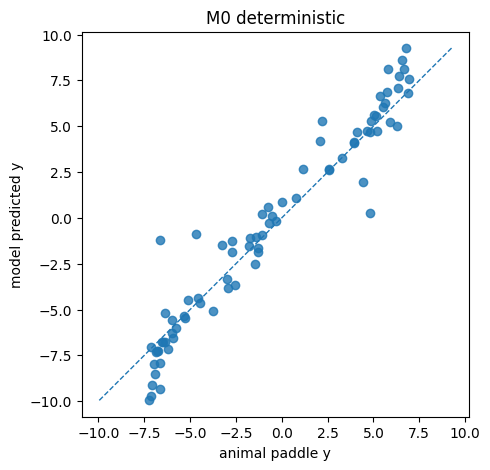

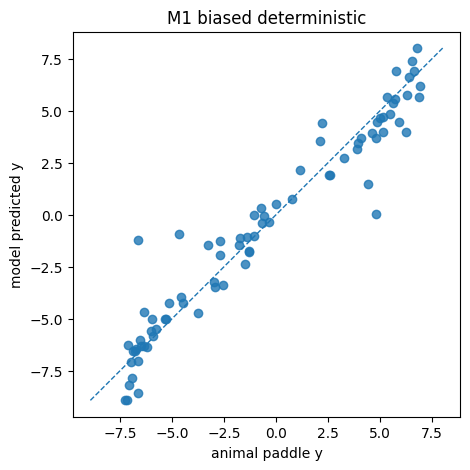

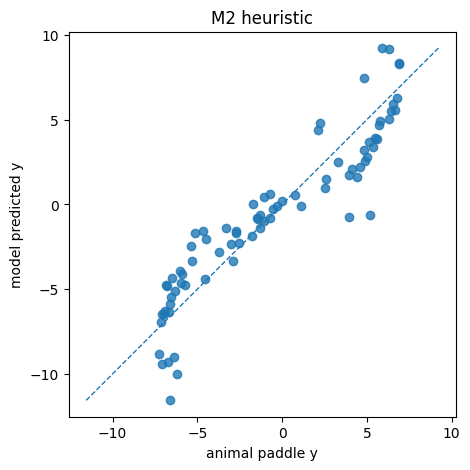

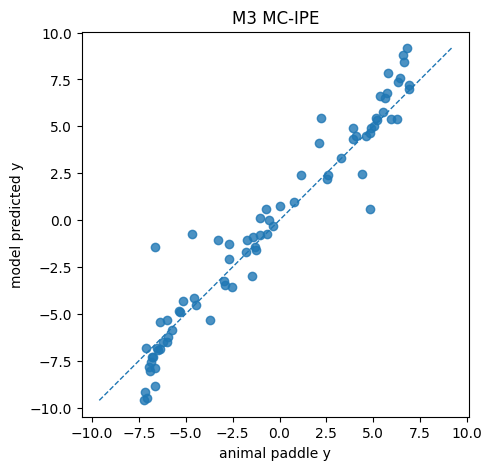

In [22]:
# some plots

models_to_plot = [
    ("M0 deterministic", "pred_M0_det"),
    ("M1 biased deterministic", "pred_M1_biased_det"),
    ("M2 heuristic", "pred_M2_heuristic"),
    ("M3 MC-IPE", "pred_M3_mc_ipe"),
]

for title, col in models_to_plot:
    plt.figure(figsize=(5, 5))
    
    plt.scatter(pred_df["y_paddle"], pred_df[col], alpha=0.8)
    
    lims = [
        min(pred_df["y_paddle"].min(), pred_df[col].min()),
        max(pred_df["y_paddle"].max(), pred_df[col].max()),
    ]
    
    plt.plot(lims, lims, linestyle="--", linewidth=1)
    plt.xlabel("animal paddle y")
    plt.ylabel("model predicted y")
    plt.title(title)
    plt.axis("equal")
    plt.show()

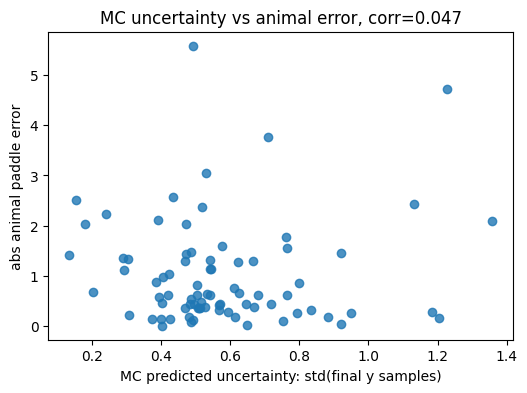

corr uncertainty vs abs paddle error: 0.046514900018085545


In [23]:
## does M3 uncertainty explains behavior bias??

valid = np.isfinite(pred_df["uncertainty_M3_mc_ipe"]) & np.isfinite(pred_df["abs_paddle_error"])

x = pred_df.loc[valid, "uncertainty_M3_mc_ipe"].values
y = pred_df.loc[valid, "abs_paddle_error"].values

corr_unc_error = np.corrcoef(x, y)[0, 1] if len(x) >= 2 else np.nan

plt.figure(figsize=(6, 4))
plt.scatter(x, y, alpha=0.8)
plt.xlabel("MC predicted uncertainty: std(final y samples)")
plt.ylabel("abs animal paddle error")
plt.title(f"MC uncertainty vs animal error, corr={corr_unc_error:.3f}")
plt.show()

print("corr uncertainty vs abs paddle error:", corr_unc_error)

,uncertainty_M3_mc_ipe,abs_paddle_error,abs_y_occ,abs_vy_occ,n_steps,n_bounce,y_occ,vy_occ
uncertainty_M3_mc_ipe,1.000000,0.046515,-0.130792,-0.126653,0.376010,-0.026892,0.144373,-0.061029
abs_paddle_error,0.046515,1.000000,0.373604,0.458426,0.216102,0.090268,0.001813,0.028558
abs_y_occ,-0.130792,0.373604,1.000000,0.056582,0.005773,0.141682,0.051033,-0.045852
abs_vy_occ,-0.126653,0.458426,0.056582,1.000000,-0.232536,0.093025,-0.065977,-0.028642
n_steps,0.376010,0.216102,0.005773,-0.232536,1.000000,-0.053405,-0.017988,-0.015667
n_bounce,-0.026892,0.090268,0.141682,0.093025,-0.053405,1.000000,0.082641,0.045897
y_occ,0.144373,0.001813,0.051033,-0.065977,-0.017988,0.082641,1.000000,0.176913
vy_occ,-0.061029,0.028558,-0.045852,-0.028642,-0.015667,0.045897,0.176913,1.000000


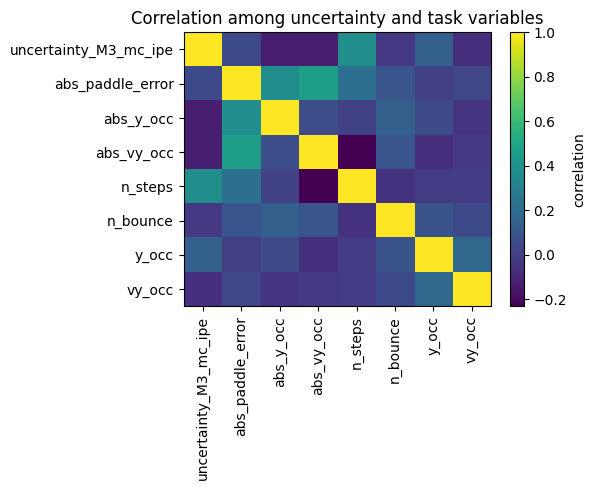

In [24]:
## MC certainty and condition 특성 비교

unc_cols = [
    "uncertainty_M3_mc_ipe",
    "abs_paddle_error",
    "abs_y_occ",
    "abs_vy_occ",
    "n_steps",
    "n_bounce",
    "y_occ",
    "vy_occ",
]

unc_cols = [c for c in unc_cols if c in pred_df.columns]

corr_table = pred_df[unc_cols].corr()

display(corr_table)

plt.figure(figsize=(6, 5))
plt.imshow(corr_table.values, aspect="auto")
plt.xticks(range(len(corr_table.columns)), corr_table.columns, rotation=90)
plt.yticks(range(len(corr_table.index)), corr_table.index)
plt.colorbar(label="correlation")
plt.title("Correlation among uncertainty and task variables")
plt.tight_layout()
plt.show()

In [25]:
model_comparison_path = PROCESSED_DIR / "behavior_model_comparison_mahler.csv"
model_summary_path = PROCESSED_DIR / "behavior_model_summary_mahler.csv"
mc_grid_path = PROCESSED_DIR / "mc_ipe_grid_search_mahler.csv"
pred_path = PROCESSED_DIR / "behavior_model_predictions_mahler.csv"

all_cv.to_csv(model_comparison_path, index=False)
summary.to_csv(model_summary_path, index=False)
mc_grid.to_csv(mc_grid_path, index=False)
pred_df.to_csv(pred_path, index=False)

print("Saved:", model_comparison_path)
print("Saved:", model_summary_path)
print("Saved:", mc_grid_path)
print("Saved:", pred_path)

Saved: c:\Users\ksbong\Documents\GitHub\ipe-pong-latents\data\processed\behavior_model_comparison_mahler.csv
Saved: c:\Users\ksbong\Documents\GitHub\ipe-pong-latents\data\processed\behavior_model_summary_mahler.csv
Saved: c:\Users\ksbong\Documents\GitHub\ipe-pong-latents\data\processed\mc_ipe_grid_search_mahler.csv
Saved: c:\Users\ksbong\Documents\GitHub\ipe-pong-latents\data\processed\behavior_model_predictions_mahler.csv


단순 MC-IPE 모델은
행동을 확률적 mental simulation 으로 설명한다는 강한 증거를 주지는 못함

오히려 지금 결과는 biased deterministic model이 가장 강한 설명 후보

현재 MC 모델이 예측한 uncertainty 는 동물의 paddle error를 거의 설명하지 못함
(Since uncertainty vs animal error corr = 0.047 $\approx 0$)

Deterministic physics는 실제 ball trajectory를 거의 완벽하게 재현했다.
따라서 핵심은 물리 예측 자체가 아니라, animal paddle response가 ground-truth prediction에서 어떻게 벗어나는지였다.

행동 모델 비교 결과, 단순 state-noise 기반 MC-IPE 는
deterministic model 보다 약간 나았지만, gain/offset bias를 허용한 biased deterministic model을 넘지는 못했다.

또한 MC certinty와 animal error의 상관이 거의 없었기 때문에, 현재 단순 MC-IPE는 행동 오차 구조를 충분히 설명하지 못한다.

In [26]:
## M4: Biased MC-IPE

def evaluate_m4_biased_mc_ipe_given_params(
    df,
    splits,
    sigma_y,
    sigma_vy,
    K,
    c_uncertainty=1.0,
    base_seed=0,
):
    mc_mean, mc_std = compute_mc_predictions_for_df(
        df,
        sigma_y=sigma_y,
        sigma_vy=sigma_vy,
        K=K,
        base_seed=base_seed,
        y_min=Y_MIN,
        y_max=Y_MAX,
    )
    
    rows = []
    preds = np.full(len(df), np.nan)
    sigmas = np.full(len(df), np.nan)
    uncertainties = np.full(len(df), np.nan)
    
    for fold, (train_idx, test_idx) in enumerate(splits):
        train_y = df.iloc[train_idx]["y_paddle"].values
        test_y = df.iloc[test_idx]["y_paddle"].values
        
        X_train = mc_mean[train_idx]
        X_test = mc_mean[test_idx]
        
        # Fit gain/offset: y_paddle = a * mc_mean + b
        beta = fit_linear_regression(X_train, train_y, add_intercept=True)
        
        train_mu = predict_linear_regression(X_train, beta, add_intercept=True)
        test_mu = predict_linear_regression(X_test, beta, add_intercept=True)
        
        residual_train = train_y - train_mu
        sigma_motor = fit_sigma_from_residuals(residual_train)
        
        test_mc_std = mc_std[test_idx]
        test_sigma = np.sqrt(c_uncertainty * (test_mc_std ** 2) + sigma_motor ** 2)
        
        nll = gaussian_nll(test_y, test_mu, test_sigma)
        
        preds[test_idx] = test_mu
        sigmas[test_idx] = test_sigma
        uncertainties[test_idx] = test_mc_std
        
        rows.append({
            "model": "M4_biased_mc_ipe",
            "fold": fold,
            "K": K,
            "sigma_y": sigma_y,
            "sigma_vy": sigma_vy,
            "c_uncertainty": c_uncertainty,
            "intercept_b": beta[0],
            "gain_a": beta[1],
            "sigma_motor": sigma_motor,
            "mean_mc_std_test": np.mean(test_mc_std),
            "mean_nll": np.mean(nll),
            **regression_metrics(test_mu, test_y),
        })
    
    return pd.DataFrame(rows), preds, sigmas, uncertainties

In [27]:
c_grid = [0.0, 0.25, 0.5, 1.0, 2.0]

m4_grid_rows = []

for K, sigma_y, sigma_vy, c_unc in itertools.product(
    K_grid,
    sigma_y_grid,
    sigma_vy_grid,
    c_grid,
):
    cv_df, _, _, _ = evaluate_m4_biased_mc_ipe_given_params(
        df,
        splits,
        sigma_y=sigma_y,
        sigma_vy=sigma_vy,
        K=K,
        c_uncertainty=c_unc,
        base_seed=123,
    )
    
    m4_grid_rows.append({
        "K": K,
        "sigma_y": sigma_y,
        "sigma_vy": sigma_vy,
        "c_uncertainty": c_unc,
        "mean_nll": cv_df["mean_nll"].mean(),
        "mean_mae": cv_df["mae"].mean(),
        "mean_rmse": cv_df["rmse"].mean(),
        "mean_corr": cv_df["corr"].mean(),
        "mean_gain_a": cv_df["gain_a"].mean(),
        "mean_intercept_b": cv_df["intercept_b"].mean(),
        "mean_mc_std_test": cv_df["mean_mc_std_test"].mean(),
    })

m4_grid = pd.DataFrame(m4_grid_rows).sort_values("mean_nll")

display(m4_grid.head(20))

,K,sigma_y,sigma_vy,c_uncertainty,mean_nll,mean_mae,mean_rmse,mean_corr,mean_gain_a,mean_intercept_b,mean_mc_std_test
646,50,0.00,0.100,0.25,1.629098,0.822282,1.211059,0.963920,0.889425,-0.272151,1.689657
671,50,0.25,0.100,0.25,1.629340,0.819842,1.208036,0.963944,0.889590,-0.269397,1.707261
696,50,0.50,0.100,0.25,1.631096,0.815476,1.203804,0.964014,0.891129,-0.266882,1.752315
721,50,0.75,0.100,0.25,1.634211,0.810140,1.198144,0.964110,0.894046,-0.265345,1.822012
641,50,0.00,0.075,0.25,1.637911,0.841939,1.220794,0.963967,0.880183,-0.255951,1.295790
666,50,0.25,0.075,0.25,1.638313,0.837930,1.216389,0.964018,0.880463,-0.254072,1.319190
691,50,0.50,0.075,0.25,1.639502,0.832148,1.210509,0.964122,0.881727,-0.253197,1.382706
746,50,1.00,0.100,0.25,1.639732,0.805112,1.192543,0.964194,0.897948,-0.264150,1.914770
716,50,0.75,0.075,0.25,1.641525,0.824084,1.203471,0.964266,0.884157,-0.253178,1.478168
741,50,1.00,0.075,0.25,1.645024,0.815530,1.195666,0.964417,0.887686,-0.253895,1.598990


In [28]:
# best M4 evaluation

best_m4 = m4_grid.iloc[0].to_dict()
best_m4

{'K': 50.0,
 'sigma_y': 0.0,
 'sigma_vy': 0.1,
 'c_uncertainty': 0.25,
 'mean_nll': 1.629097568058167,
 'mean_mae': 0.8222815091819143,
 'mean_rmse': 1.2110585647148056,
 'mean_corr': 0.9639196315832528,
 'mean_gain_a': 0.889425143512045,
 'mean_intercept_b': -0.2721505412054568,
 'mean_mc_std_test': 1.68965739073451}

In [29]:
m4_cv, m4_pred, m4_sigma, m4_uncertainty = evaluate_m4_biased_mc_ipe_given_params(
    df,
    splits,
    sigma_y=best_m4["sigma_y"],
    sigma_vy=best_m4["sigma_vy"],
    K=int(best_m4["K"]),
    c_uncertainty=best_m4["c_uncertainty"],
    base_seed=123,
)

display(m4_cv)
display(m4_cv.mean(numeric_only=True))

,model,fold,K,sigma_y,sigma_vy,c_uncertainty,intercept_b,gain_a,sigma_motor,mean_mc_std_test,mean_nll,n,mae,rmse,corr
0,M4_biased_mc_ipe,0,50,0.0,0.1,0.25,-0.200993,0.893349,1.334259,1.698410,1.560844,16,0.634541,0.893004,0.986726
1,M4_biased_mc_ipe,1,50,0.0,0.1,0.25,-0.370866,0.876698,1.339297,1.655196,1.532630,16,0.687142,0.886471,0.988443
2,M4_biased_mc_ipe,2,50,0.0,0.1,0.25,-0.261863,0.881945,0.995013,1.848573,1.834386,16,1.089107,1.972810,0.901855
3,M4_biased_mc_ipe,3,50,0.0,0.1,0.25,-0.207388,0.891517,1.262305,1.698984,1.631187,16,0.913578,1.236062,0.959771
4,M4_biased_mc_ipe,4,50,0.0,0.1,0.25,-0.319642,0.903617,1.299758,1.547123,1.586441,15,0.787039,1.066946,0.982802


fold                 2.000000
K                   50.000000
sigma_y              0.000000
sigma_vy             0.100000
c_uncertainty        0.250000
intercept_b         -0.272151
gain_a               0.889425
sigma_motor          1.246126
mean_mc_std_test     1.689657
mean_nll             1.629098
n                   15.800000
mae                  0.822282
rmse                 1.211059
corr                 0.963920
dtype: float64

In [30]:
# M0 ~ M4 다시 비교

all_cv_v2 = pd.concat([m0_cv, m1_cv, m2_cv, m3_cv, m4_cv], ignore_index=True)

summary_v2 = (
    all_cv_v2
    .groupby("model")
    .agg(
        mean_nll=("mean_nll", "mean"),
        sem_nll=("mean_nll", lambda x: x.std(ddof=1) / np.sqrt(len(x))),
        mean_mae=("mae", "mean"),
        mean_rmse=("rmse", "mean"),
        mean_corr=("corr", "mean"),
    )
    .reset_index()
    .sort_values("mean_nll")
)

display(summary_v2)

,model,mean_nll,sem_nll,mean_mae,mean_rmse,mean_corr
4,M4_biased_mc_ipe,1.629098,0.053820,0.822282,1.211059,0.963920
1,M1_biased_deterministic,1.758013,0.215236,0.883269,1.242161,0.964047
3,M3_mc_ipe,1.766112,0.075887,0.971310,1.360107,0.966375
0,M0_deterministic_motor_noise,1.823189,0.120636,1.019783,1.406527,0.964047
2,M2_heuristic_linear,2.167375,0.136947,1.566818,1.923193,0.935947


동물의 paddle response는 단순 deterministic physics 만으로는 부족하고,
gain/offset bias 를 고려하면 많이 좋아짐.

그런데 그 위에
Battaglia-style noisy simulation componenet를 추가하면 NLL 과 error 가 더 줄어듬

단순 MC-IPE 모델은 biased deterministic model을 넘지 못했지만,
reponse gain/offset bias를 함께 포함한 MC-IPE 모델은 M1 보다 더 낮은 NLL과 error를 보였다.
따라서 행동 데이터 수준에서는 동물의 response가 단순한
deterministic prediction의 linear transform만으로는 완전히 설명되지 않고, noisy internal simulation componenet가 추가 설명력을 가질 가능성이 있다.

In [31]:
compare_m1_m4 = (
    m1_cv[["fold", "mean_nll", "mae", "rmse"]]
    .rename(columns={
        "mean_nll": "m1_nll",
        "mae": "m1_mae",
        "rmse": "m1_rmse",
    })
    .merge(
        m4_cv[["fold", "mean_nll", "mae", "rmse"]]
        .rename(columns={
            "mean_nll": "m4_nll",
            "mae": "m4_mae",
            "rmse": "m4_rmse",
        }),
        on="fold"
    )
)

compare_m1_m4["delta_nll_m1_minus_m4"] = compare_m1_m4["m1_nll"] - compare_m1_m4["m4_nll"]
compare_m1_m4["delta_mae_m1_minus_m4"] = compare_m1_m4["m1_mae"] - compare_m1_m4["m4_mae"]
compare_m1_m4["delta_rmse_m1_minus_m4"] = compare_m1_m4["m1_rmse"] - compare_m1_m4["m4_rmse"]

display(compare_m1_m4)
display(compare_m1_m4.describe())

,fold,m1_nll,m1_mae,m1_rmse,m4_nll,m4_mae,m4_rmse,delta_nll_m1_minus_m4,delta_mae_m1_minus_m4,delta_rmse_m1_minus_m4
0,0,1.446338,0.717805,0.915067,1.560844,0.634541,0.893004,-0.114507,0.083264,0.022062
1,1,1.433630,0.719129,0.878233,1.532630,0.687142,0.886471,-0.099001,0.031987,-0.008237
2,2,2.586865,1.050279,1.893667,1.834386,1.089107,1.972810,0.752480,-0.038828,-0.079142
3,3,1.758013,1.085197,1.385001,1.631187,0.913578,1.236062,0.126827,0.171619,0.148938
4,4,1.565220,0.843934,1.138838,1.586441,0.787039,1.066946,-0.021221,0.056896,0.071892


,fold,m1_nll,m1_mae,m1_rmse,m4_nll,m4_mae,m4_rmse,delta_nll_m1_minus_m4,delta_mae_m1_minus_m4,delta_rmse_m1_minus_m4
count,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000
mean,2.000000,1.758013,0.883269,1.242161,1.629098,0.822282,1.211059,0.128916,0.060987,0.031103
std,1.581139,0.481283,0.176447,0.416825,0.120345,0.183223,0.449493,0.361448,0.076741,0.085633
min,0.000000,1.433630,0.717805,0.878233,1.532630,0.634541,0.886471,-0.114507,-0.038828,-0.079142
25%,1.000000,1.446338,0.719129,0.915067,1.560844,0.687142,0.893004,-0.099001,0.031987,-0.008237
50%,2.000000,1.565220,0.843934,1.138838,1.586441,0.787039,1.066946,-0.021221,0.056896,0.022062
75%,3.000000,1.758013,1.050279,1.385001,1.631187,0.913578,1.236062,0.126827,0.083264,0.071892
max,4.000000,2.586865,1.085197,1.893667,1.834386,1.089107,1.972810,0.752480,0.171619,0.148938


또 fold 별로 보면 모든 fold 에서 안정적으로 M4 가 더 좋은 것은 아닌 걸로 보인다.

근데 m4 best 의 K=50임.
Battaglia et al. 에서
human like 는 K=3,5,7 정도가 좋다고 언급했었음.

K는 3-7로 제한했을 때 유사한 경향이 유지되는지 확인할 필요가 있음.

In [32]:
m4_few_sample = m4_grid[m4_grid["K"].isin([1, 3, 5, 7, 10])].sort_values("mean_nll")
display(m4_few_sample.head(20))

,K,sigma_y,sigma_vy,c_uncertainty,mean_nll,mean_mae,mean_rmse,mean_corr,mean_gain_a,mean_intercept_b,mean_mc_std_test
287,5,0.25,0.050,0.50,1.653964,0.922055,1.247068,0.966200,0.877422,-0.264329,0.794135
509,10,0.00,0.025,2.00,1.654289,0.907270,1.267999,0.963557,0.872048,-0.215633,0.434507
284,5,0.25,0.025,2.00,1.656532,0.882898,1.225779,0.965944,0.878583,-0.239867,0.440075
262,5,0.00,0.050,0.50,1.657622,0.929075,1.254673,0.965742,0.874258,-0.259949,0.756415
312,5,0.50,0.050,0.50,1.658465,0.916252,1.241734,0.966478,0.881534,-0.270404,0.880516
388,7,0.00,0.050,1.00,1.659932,0.857327,1.237164,0.964140,0.878950,-0.187516,0.801729
263,5,0.00,0.050,1.00,1.661771,0.929075,1.254673,0.965742,0.874258,-0.259949,0.756415
288,5,0.25,0.050,1.00,1.661948,0.922055,1.247068,0.966200,0.877422,-0.264329,0.794135
259,5,0.00,0.025,2.00,1.662747,0.897513,1.241756,0.965308,0.873182,-0.234688,0.383859
286,5,0.25,0.050,0.25,1.664742,0.922055,1.247068,0.966200,0.877422,-0.264329,0.794135


In [33]:
m4_best_by_K = (
    m4_grid
    .sort_values("mean_nll")
    .groupby("K")
    .head(1)
    .sort_values("K")
)

display(m4_best_by_K)

,K,sigma_y,sigma_vy,c_uncertainty,mean_nll,mean_mae,mean_rmse,mean_corr,mean_gain_a,mean_intercept_b,mean_mc_std_test
6,1,0.00,0.025,0.25,1.731823,0.966393,1.293794,0.963556,0.865104,-0.209262,0.000000
134,3,0.00,0.025,2.00,1.721509,0.863833,1.227128,0.963739,0.869777,-0.183372,0.335794
287,5,0.25,0.050,0.50,1.653964,0.922055,1.247068,0.966200,0.877422,-0.264329,0.794135
388,7,0.00,0.050,1.00,1.659932,0.857327,1.237164,0.964140,0.878950,-0.187516,0.801729
509,10,0.00,0.025,2.00,1.654289,0.907270,1.267999,0.963557,0.872048,-0.215633,0.434507
646,50,0.00,0.100,0.25,1.629098,0.822282,1.211059,0.963920,0.889425,-0.272151,1.689657


In [34]:
# fold 2 에서 큰 향상이 있었으므로 condition 들을 확인

fold_id = 2
_, test_idx = splits[fold_id]

fold2_df = pred_df.iloc[test_idx].copy()

fold2_df["m1_abs_error"] = np.abs(fold2_df["y_paddle"] - fold2_df["pred_M1_biased_det"])
fold2_df["m4_abs_error"] = np.abs(fold2_df["y_paddle"] - m4_pred[test_idx])
fold2_df["m1_to_m4_abs_error_delta"] = fold2_df["m1_abs_error"] - fold2_df["m4_abs_error"]

cols = [
    "condition_i",
    "y_paddle",
    "y_true",
    "y_det",
    "pred_M1_biased_det",
    "m1_abs_error",
    "m4_abs_error",
    "m1_to_m4_abs_error_delta",
    "y_occ",
    "vy_occ",
    "n_steps",
    "n_bounce",
]

cols = [c for c in cols if c in fold2_df.columns]
display(fold2_df[cols].sort_values("m1_to_m4_abs_error_delta", ascending=False))

,condition_i,y_paddle,y_true,y_det,pred_M1_biased_det,m1_abs_error,m4_abs_error,m1_to_m4_abs_error_delta,y_occ,vy_occ,n_steps,n_bounce
72,72,-6.013120,-6.291844,-6.291844,-5.608922,0.404197,0.062515,0.341683,-1.259022,-0.264885,19,0.0
31,31,-0.733576,0.612923,0.612923,0.343817,1.077392,0.939479,0.137913,3.040649,-0.173409,14,0.0
20,20,6.894891,6.458145,6.800323,5.678099,1.216792,1.094991,0.121801,8.431740,0.264885,18,1.0
9,9,-6.741161,-6.920723,-7.272516,-6.454379,0.286781,0.174258,0.112523,-8.872451,-0.226767,17,0.0
32,32,-6.527717,-6.787429,-6.787430,-6.036177,0.491540,0.397894,0.093646,-4.186296,-0.173409,15,1.0
48,48,-7.106050,-6.746262,-7.060200,-6.271337,0.834713,0.772125,0.062588,-8.832883,-0.241583,17,0.0
52,52,-6.190933,-6.842524,-7.177869,-6.372782,0.181849,0.139775,0.042074,-9.792950,-0.097716,31,1.0
16,16,5.015811,5.635467,5.635467,4.673853,0.341958,0.329381,0.012577,0.688428,0.260370,19,1.0
39,39,-5.919218,-6.543676,-6.543676,-5.826032,0.093186,0.140043,-0.046857,-1.426503,-0.269325,19,0.0
51,51,-6.634466,-1.052173,-1.213678,-1.230933,5.403533,5.452701,-0.049168,-9.070737,-0.335020,29,0.0


In [35]:
# Best M4 prediction/sigma가 이미 m4_pred, m4_sigma에 들어있다고 가정
# M1 prediction/sigma는 m1_pred, m1_sigma

diagnostic_df = pred_df.copy()

diagnostic_df["m1_mu"] = m1_pred
diagnostic_df["m1_sigma"] = m1_sigma
diagnostic_df["m4_mu"] = m4_pred
diagnostic_df["m4_sigma"] = m4_sigma
diagnostic_df["m4_uncertainty"] = m4_uncertainty

diagnostic_df["m1_nll_point"] = gaussian_nll(
    diagnostic_df["y_paddle"].values,
    diagnostic_df["m1_mu"].values,
    diagnostic_df["m1_sigma"].values,
)

diagnostic_df["m4_nll_point"] = gaussian_nll(
    diagnostic_df["y_paddle"].values,
    diagnostic_df["m4_mu"].values,
    diagnostic_df["m4_sigma"].values,
)

diagnostic_df["delta_nll_m1_minus_m4"] = (
    diagnostic_df["m1_nll_point"] - diagnostic_df["m4_nll_point"]
)

diagnostic_df["m1_abs_error"] = np.abs(
    diagnostic_df["y_paddle"] - diagnostic_df["m1_mu"]
)

diagnostic_df["m4_abs_error"] = np.abs(
    diagnostic_df["y_paddle"] - diagnostic_df["m4_mu"]
)

diagnostic_df["delta_abs_error_m1_minus_m4"] = (
    diagnostic_df["m1_abs_error"] - diagnostic_df["m4_abs_error"]
)

cols = [
    "condition_i",
    "y_paddle",
    "y_true",
    "y_det",
    "m1_mu",
    "m4_mu",
    "m1_sigma",
    "m4_sigma",
    "m4_uncertainty",
    "m1_nll_point",
    "m4_nll_point",
    "delta_nll_m1_minus_m4",
    "m1_abs_error",
    "m4_abs_error",
    "delta_abs_error_m1_minus_m4",
    "y_occ",
    "vy_occ",
    "n_steps",
    "n_bounce",
]

cols = [c for c in cols if c in diagnostic_df.columns]

display(
    diagnostic_df[cols]
    .sort_values("delta_nll_m1_minus_m4", ascending=False)
    .head(20)
)

display(
    diagnostic_df[cols]
    .sort_values("delta_nll_m1_minus_m4", ascending=True)
    .head(20)
)

,condition_i,y_paddle,y_true,y_det,m1_mu,m4_mu,m1_sigma,m4_sigma,m4_uncertainty,m1_nll_point,m4_nll_point,delta_nll_m1_minus_m4,m1_abs_error,m4_abs_error,delta_abs_error_m1_minus_m4,y_occ,vy_occ,n_steps,n_bounce
51,51,-6.634466,-1.052173,-1.213678,-1.230933,-1.181765,1.053356,1.664196,2.667957,14.128467,6.795933,7.332534,5.403533,5.452701,-0.049168,-9.070737,-0.335020,29,0.0
75,75,4.836395,0.114265,0.287361,0.063143,-0.404510,1.053356,2.207507,3.941085,11.238025,4.529044,6.708981,4.773252,5.240904,-0.467652,7.531867,0.348022,35,1.0
38,38,-4.666365,-0.900870,-0.900872,-0.936645,-0.949556,1.239052,1.631572,2.067475,5.663757,4.003248,1.660509,3.729720,3.716809,0.012911,-7.020894,0.291430,21,1.0
3,3,-7.246475,-9.766393,-9.952948,-8.925939,-8.132695,1.239052,1.327884,0.824287,2.051898,1.425231,0.626666,1.679464,0.886220,0.793244,-4.450462,-0.423268,13,1.0
41,41,-6.639249,-9.006832,-9.333518,-8.572161,-7.903959,1.301134,1.412698,1.106970,2.285618,1.665171,0.620447,1.932912,1.264710,0.668202,-4.485969,-0.294310,21,0.0
14,14,-7.153478,-9.718668,-9.718668,-8.915374,-8.226118,1.301134,1.381180,0.934428,2.099000,1.543440,0.555560,1.761896,1.072640,0.689256,-6.678587,-0.190005,16,1.0
30,30,-3.279467,-1.498701,-1.498701,-1.464285,-1.785301,1.239052,1.624984,2.046616,2.206363,1.827172,0.379190,1.815182,1.494165,0.321016,-6.102190,0.255749,18,1.0
34,34,6.784557,8.901912,9.259599,8.030909,7.482180,1.239052,1.363126,1.028979,1.639194,1.359680,0.279515,1.246353,0.697624,0.548729,5.707579,0.264885,19,1.0
36,36,4.412908,1.982349,1.982349,1.511578,1.342483,1.301134,1.490116,1.457499,3.668284,3.440679,0.227605,2.901330,3.070425,-0.169095,7.555935,-0.278679,20,0.0
78,78,6.288502,4.805050,5.006808,3.972852,3.883157,1.356974,1.613573,1.799894,2.680235,2.508475,0.171760,2.315651,2.405345,-0.089694,9.631794,0.282179,19,1.0


,condition_i,y_paddle,y_true,y_det,m1_mu,m4_mu,m1_sigma,m4_sigma,m4_uncertainty,m1_nll_point,m4_nll_point,delta_nll_m1_minus_m4,m1_abs_error,m4_abs_error,delta_abs_error_m1_minus_m4,y_occ,vy_occ,n_steps,n_bounce
65,65,-5.127701,-4.497666,-4.497666,-4.262861,-3.775466,1.301134,1.936313,2.870498,1.403076,1.823575,-0.420499,0.864840,1.352235,-0.487395,-0.839668,-0.110848,33,0.0
60,60,-4.543344,-4.355982,-4.355982,-3.951016,-3.712767,1.343921,2.062443,3.145425,1.311658,1.723920,-0.412261,0.592328,0.830577,-0.238249,-0.249066,-0.120792,34,1.0
76,76,-5.285330,-5.444082,-5.444082,-5.012974,-4.503998,1.356974,1.804403,2.418393,1.244338,1.602919,-0.358581,0.272357,0.781333,-0.508976,-3.012649,-0.081048,30,0.0
58,58,3.937104,4.156364,4.156228,3.474969,4.021807,1.343921,2.025963,3.049119,1.273653,1.625858,-0.352205,0.462135,0.084703,0.377432,0.049311,0.120792,34,0.0
52,52,-6.190933,-6.842524,-7.177869,-6.372782,-6.330708,1.053356,1.407624,1.991337,0.985822,1.265772,-0.279950,0.181849,0.139775,0.042074,-9.792950,-0.097716,31,1.0
74,74,0.778353,1.090186,1.090186,0.755274,1.050663,1.053356,1.349668,1.823792,0.971160,1.239151,-0.267991,0.023079,0.272310,-0.249231,-3.016731,0.241583,17,0.0
62,62,-0.322088,-0.178918,-0.178918,-0.338846,-0.627542,1.053356,1.334332,1.778080,0.971047,1.233571,-0.262525,0.016758,0.305454,-0.288696,-3.305816,0.195431,16,0.0
8,8,5.357863,6.663910,6.663910,5.683388,5.950431,1.301134,1.604011,1.879875,1.213471,1.459685,-0.246214,0.325525,0.592568,-0.267043,2.475338,0.246387,17,1.0
39,39,-5.919218,-6.543676,-6.543676,-5.826032,-6.059261,1.053356,1.331961,1.770956,0.974833,1.211118,-0.236285,0.093186,0.140043,-0.046857,-1.426503,-0.269325,19,0.0
77,77,-5.342333,-5.351133,-5.351221,-5.023476,-5.662197,1.301134,1.655433,2.050453,1.212202,1.441668,-0.229466,0.318856,0.319865,-0.001008,-2.583345,-0.092263,30,0.0


In [36]:
def evaluate_m4_uncertainty_only_given_params(
    df,
    splits,
    sigma_y,
    sigma_vy,
    K,
    c_uncertainty=1.0,
    base_seed=0,
):
    """
    Mean is biased deterministic prediction: a * y_det + b.
    Variance uses MC uncertainty.
    
    This tests whether MC uncertainty alone improves likelihood
    beyond biased deterministic mean.
    """
    mc_mean, mc_std = compute_mc_predictions_for_df(
        df,
        sigma_y=sigma_y,
        sigma_vy=sigma_vy,
        K=K,
        base_seed=base_seed,
        y_min=Y_MIN,
        y_max=Y_MAX,
    )
    
    rows = []
    preds = np.full(len(df), np.nan)
    sigmas = np.full(len(df), np.nan)
    uncertainties = np.full(len(df), np.nan)
    
    for fold, (train_idx, test_idx) in enumerate(splits):
        train = df.iloc[train_idx]
        test = df.iloc[test_idx]
        
        train_y = train["y_paddle"].values
        test_y = test["y_paddle"].values
        
        # Fit biased deterministic mean
        X_train = train["y_det"].values
        X_test = test["y_det"].values
        
        beta = fit_linear_regression(X_train, train_y, add_intercept=True)
        
        train_mu = predict_linear_regression(X_train, beta, add_intercept=True)
        test_mu = predict_linear_regression(X_test, beta, add_intercept=True)
        
        residual_train = train_y - train_mu
        sigma_motor = fit_sigma_from_residuals(residual_train)
        
        test_mc_std = mc_std[test_idx]
        test_sigma = np.sqrt(c_uncertainty * (test_mc_std ** 2) + sigma_motor ** 2)
        
        nll = gaussian_nll(test_y, test_mu, test_sigma)
        
        preds[test_idx] = test_mu
        sigmas[test_idx] = test_sigma
        uncertainties[test_idx] = test_mc_std
        
        rows.append({
            "model": "M4_uncertainty_only",
            "fold": fold,
            "K": K,
            "sigma_y": sigma_y,
            "sigma_vy": sigma_vy,
            "c_uncertainty": c_uncertainty,
            "intercept_b": beta[0],
            "gain_a": beta[1],
            "sigma_motor": sigma_motor,
            "mean_mc_std_test": np.mean(test_mc_std),
            "mean_nll": np.mean(nll),
            **regression_metrics(test_mu, test_y),
        })
    
    return pd.DataFrame(rows), preds, sigmas, uncertainties

In [37]:
m4_unc_only_cv, m4_unc_only_pred, m4_unc_only_sigma, m4_unc_only_uncertainty = (
    evaluate_m4_uncertainty_only_given_params(
        df,
        splits,
        sigma_y=best_m4["sigma_y"],
        sigma_vy=best_m4["sigma_vy"],
        K=int(best_m4["K"]),
        c_uncertainty=best_m4["c_uncertainty"],
        base_seed=123,
    )
)

display(m4_unc_only_cv)
display(m4_unc_only_cv.mean(numeric_only=True))

,model,fold,K,sigma_y,sigma_vy,c_uncertainty,intercept_b,gain_a,sigma_motor,mean_mc_std_test,mean_nll,n,mae,rmse,corr
0,M4_uncertainty_only,0,50,0.0,0.1,0.25,-0.150891,0.872392,1.343921,1.698410,1.565264,16,0.717805,0.915067,0.985461
1,M4_uncertainty_only,1,50,0.0,0.1,0.25,-0.332074,0.859814,1.356974,1.655196,1.538895,16,0.719129,0.878233,0.990969
2,M4_uncertainty_only,2,50,0.0,0.1,0.25,-0.184597,0.862120,1.053356,1.848573,1.811906,16,1.050279,1.893667,0.912236
3,M4_uncertainty_only,3,50,0.0,0.1,0.25,-0.141543,0.882592,1.239052,1.698984,1.718338,16,1.085197,1.385001,0.950667
4,M4_uncertainty_only,4,50,0.0,0.1,0.25,-0.254923,0.891115,1.301134,1.547123,1.639050,15,0.843934,1.138838,0.980905


fold                 2.000000
K                   50.000000
sigma_y              0.000000
sigma_vy             0.100000
c_uncertainty        0.250000
intercept_b         -0.212805
gain_a               0.873607
sigma_motor          1.258887
mean_mc_std_test     1.689657
mean_nll             1.654691
n                   15.800000
mae                  0.883269
rmse                 1.242161
corr                 0.964047
dtype: float64

MC uncertainty 가 condition 별 response variability / outlier response 를 설명하는 데 실제로 기여했음.

In [38]:
## M5: heteroscedastic deterministic model

def fit_heteroscedastic_sigma_grid(
    residual_train,
    Z_train,
    alpha_grid=None,
    min_sigma=1e-3,
):
    """
    Fit condition-dependent sigma using a simple grid search.

    Model:
        sigma_i = sigma0 * exp(Z_i @ alpha)

    where:
        residual_i ~ Normal(0, sigma_i)

    We grid-search alpha values and fit sigma0 analytically for each alpha.
    """
    residual_train = np.asarray(residual_train, dtype=float)
    Z_train = np.asarray(Z_train, dtype=float)

    if alpha_grid is None:
        alpha_values = [-1.0, -0.5, 0.0, 0.5, 1.0]
        alpha_grid = list(itertools.product(alpha_values, repeat=Z_train.shape[1]))

    best = None

    for alpha in alpha_grid:
        alpha = np.asarray(alpha, dtype=float)

        scale = np.exp(Z_train @ alpha)
        scale = np.maximum(scale, min_sigma)

        # For residual_i ~ Normal(0, sigma0 * scale_i),
        # MLE sigma0^2 = mean((residual_i / scale_i)^2)
        sigma0 = np.sqrt(np.mean((residual_train / scale) ** 2))
        sigma0 = max(float(sigma0), min_sigma)

        sigma_i = sigma0 * scale
        nll = gaussian_nll(residual_train, np.zeros_like(residual_train), sigma_i)
        mean_nll = np.mean(nll)

        if best is None or mean_nll < best["mean_nll"]:
            best = {
                "alpha": alpha,
                "sigma0": sigma0,
                "mean_nll": mean_nll,
            }

    return best


def evaluate_m5_heteroscedastic_deterministic(
    df,
    splits,
    sigma_features,
    alpha_values=None,
):
    """
    M5:
        mean:  biased deterministic, a * y_det + b
        sigma: condition-dependent sigma from simple task features
    """
    rows = []
    preds = np.full(len(df), np.nan)
    sigmas = np.full(len(df), np.nan)

    if alpha_values is None:
        alpha_values = [-1.0, -0.5, 0.0, 0.5, 1.0]

    for fold, (train_idx, test_idx) in enumerate(splits):
        train = df.iloc[train_idx]
        test = df.iloc[test_idx]

        # 1. Fit biased deterministic mean
        X_train = train["y_det"].values
        y_train = train["y_paddle"].values

        X_test = test["y_det"].values
        y_test = test["y_paddle"].values

        beta_mean = fit_linear_regression(X_train, y_train, add_intercept=True)

        mu_train = predict_linear_regression(X_train, beta_mean, add_intercept=True)
        mu_test = predict_linear_regression(X_test, beta_mean, add_intercept=True)

        residual_train = y_train - mu_train

        # 2. Prepare sigma features
        Z_train_raw = train[sigma_features].values
        Z_test_raw = test[sigma_features].values

        Z_train, Z_test, z_mean, z_std = standardize_train_test(Z_train_raw, Z_test_raw)

        # 3. Grid search heteroscedastic sigma parameters
        alpha_grid = list(itertools.product(alpha_values, repeat=len(sigma_features)))

        best_sigma = fit_heteroscedastic_sigma_grid(
            residual_train=residual_train,
            Z_train=Z_train,
            alpha_grid=alpha_grid,
        )

        alpha = best_sigma["alpha"]
        sigma0 = best_sigma["sigma0"]

        sigma_test = sigma0 * np.exp(Z_test @ alpha)
        sigma_test = np.maximum(sigma_test, 1e-3)

        nll = gaussian_nll(y_test, mu_test, sigma_test)

        preds[test_idx] = mu_test
        sigmas[test_idx] = sigma_test

        rows.append({
            "model": "M5_heteroscedastic_deterministic",
            "fold": fold,
            "sigma_features": ",".join(sigma_features),
            "intercept_b": beta_mean[0],
            "gain_a": beta_mean[1],
            "sigma0": sigma0,
            "alpha": alpha,
            "mean_sigma_test": np.mean(sigma_test),
            "mean_nll": np.mean(nll),
            **regression_metrics(mu_test, y_test),
        })

    return pd.DataFrame(rows), preds, sigmas

In [39]:
sigma_feature_sets = {
    "abs_vy": ["abs_vy_occ"],
    "abs_vy_nsteps": ["abs_vy_occ", "n_steps"],
    "abs_vy_abs_y": ["abs_vy_occ", "abs_y_occ"],
    "abs_vy_nsteps_abs_y": ["abs_vy_occ", "n_steps", "abs_y_occ"],
}

In [40]:
m5_results = []
m5_preds = {}
m5_sigmas = {}

for name, features in sigma_feature_sets.items():
    cv_df, pred, sigma = evaluate_m5_heteroscedastic_deterministic(
        df=df,
        splits=splits,
        sigma_features=features,
        alpha_values=[-1.0, -0.5, 0.0, 0.5, 1.0],
    )

    cv_df["feature_set"] = name

    m5_results.append(cv_df)
    m5_preds[name] = pred
    m5_sigmas[name] = sigma

m5_cv_all = pd.concat(m5_results, ignore_index=True)

m5_summary = (
    m5_cv_all
    .groupby(["model", "feature_set"])
    .agg(
        mean_nll=("mean_nll", "mean"),
        sem_nll=("mean_nll", lambda x: x.std(ddof=1) / np.sqrt(len(x))),
        mean_mae=("mae", "mean"),
        mean_rmse=("rmse", "mean"),
        mean_corr=("corr", "mean"),
        mean_sigma_test=("mean_sigma_test", "mean"),
    )
    .reset_index()
    .sort_values("mean_nll")
)

display(m5_summary)

,model,feature_set,mean_nll,sem_nll,mean_mae,mean_rmse,mean_corr,mean_sigma_test
2,M5_heteroscedastic_deterministic,abs_vy_nsteps,1.584212,0.059826,0.883269,1.242161,0.964047,1.330518
0,M5_heteroscedastic_deterministic,abs_vy,1.746827,0.230472,0.883269,1.242161,0.964047,1.198815
1,M5_heteroscedastic_deterministic,abs_vy_abs_y,1.786497,0.228548,0.883269,1.242161,0.964047,1.050798
3,M5_heteroscedastic_deterministic,abs_vy_nsteps_abs_y,2.087758,0.338928,0.883269,1.242161,0.964047,1.272785


In [41]:
## M1 M4 M5 comparison

best_m5_name = m5_summary.iloc[0]["feature_set"]
best_m5_cv = m5_cv_all[m5_cv_all["feature_set"] == best_m5_name].copy()

final_compare_cv = pd.concat(
    [
        m1_cv,
        m4_unc_only_cv,
        m4_cv,
        best_m5_cv,
    ],
    ignore_index=True,
)

final_compare_summary = (
    final_compare_cv
    .groupby("model")
    .agg(
        mean_nll=("mean_nll", "mean"),
        sem_nll=("mean_nll", lambda x: x.std(ddof=1) / np.sqrt(len(x))),
        mean_mae=("mae", "mean"),
        mean_rmse=("rmse", "mean"),
        mean_corr=("corr", "mean"),
    )
    .reset_index()
    .sort_values("mean_nll")
)

display(final_compare_summary)
print("Best M5 feature set:", best_m5_name)

,model,mean_nll,sem_nll,mean_mae,mean_rmse,mean_corr
3,M5_heteroscedastic_deterministic,1.584212,0.059826,0.883269,1.242161,0.964047
1,M4_biased_mc_ipe,1.629098,0.053820,0.822282,1.211059,0.963920
2,M4_uncertainty_only,1.654691,0.050209,0.883269,1.242161,0.964047
0,M1_biased_deterministic,1.758013,0.215236,0.883269,1.242161,0.964047


Best M5 feature set: abs_vy_nsteps


behavior data 만 보면,
MC similation-specific uncertainty 보다
$|vy_{occ}| + n_{steps}$ 로 만든 단순 task-difficulty uncertainty 가 더 강한 설명력을 보임.

In [42]:
## M6: MC mean + task-difficulty uncertainty

def evaluate_m6_mc_mean_task_uncertainty(
    df,
    splits,
    sigma_y,
    sigma_vy,
    K,
    sigma_features,
    alpha_values=None,
    base_seed=0,
):
    """
    M6:
        mean  = a * MC_mean + b
        sigma = task-difficulty-based heteroscedastic sigma

    Purpose:
        Combine M4's better point prediction with M5's better uncertainty calibration.
    """
    if alpha_values is None:
        alpha_values = [-1.0, -0.5, 0.0, 0.5, 1.0]

    # 1. Compute MC mean/std for all conditions
    mc_mean, mc_std = compute_mc_predictions_for_df(
        df,
        sigma_y=sigma_y,
        sigma_vy=sigma_vy,
        K=K,
        base_seed=base_seed,
        y_min=Y_MIN,
        y_max=Y_MAX,
    )

    rows = []
    preds = np.full(len(df), np.nan)
    sigmas = np.full(len(df), np.nan)
    mc_means_out = np.full(len(df), np.nan)
    mc_stds_out = np.full(len(df), np.nan)

    for fold, (train_idx, test_idx) in enumerate(splits):
        train = df.iloc[train_idx]
        test = df.iloc[test_idx]

        y_train = train["y_paddle"].values
        y_test = test["y_paddle"].values

        # 2. Mean model: y_paddle = a * MC_mean + b
        X_train = mc_mean[train_idx]
        X_test = mc_mean[test_idx]

        beta_mean = fit_linear_regression(X_train, y_train, add_intercept=True)

        mu_train = predict_linear_regression(X_train, beta_mean, add_intercept=True)
        mu_test = predict_linear_regression(X_test, beta_mean, add_intercept=True)

        residual_train = y_train - mu_train

        # 3. Sigma model: sigma_i depends on task-difficulty features
        Z_train_raw = train[sigma_features].values
        Z_test_raw = test[sigma_features].values

        Z_train, Z_test, z_mean, z_std = standardize_train_test(
            Z_train_raw,
            Z_test_raw,
        )

        alpha_grid = list(itertools.product(alpha_values, repeat=len(sigma_features)))

        best_sigma = fit_heteroscedastic_sigma_grid(
            residual_train=residual_train,
            Z_train=Z_train,
            alpha_grid=alpha_grid,
        )

        alpha = best_sigma["alpha"]
        sigma0 = best_sigma["sigma0"]

        sigma_test = sigma0 * np.exp(Z_test @ alpha)
        sigma_test = np.maximum(sigma_test, 1e-3)

        # 4. Evaluate likelihood
        nll = gaussian_nll(y_test, mu_test, sigma_test)

        preds[test_idx] = mu_test
        sigmas[test_idx] = sigma_test
        mc_means_out[test_idx] = mc_mean[test_idx]
        mc_stds_out[test_idx] = mc_std[test_idx]

        rows.append({
            "model": "M6_mc_mean_task_uncertainty",
            "fold": fold,
            "K": K,
            "sigma_y": sigma_y,
            "sigma_vy": sigma_vy,
            "sigma_features": ",".join(sigma_features),
            "intercept_b": beta_mean[0],
            "gain_a": beta_mean[1],
            "sigma0": sigma0,
            "alpha": alpha,
            "mean_sigma_test": np.mean(sigma_test),
            "mean_mc_std_test": np.mean(mc_std[test_idx]),
            "mean_nll": np.mean(nll),
            **regression_metrics(mu_test, y_test),
        })

    return pd.DataFrame(rows), preds, sigmas, mc_means_out, mc_stds_out

In [43]:
m6_sigma_features = ["abs_vy_occ", "n_steps"]

m6_grid_rows = []
m6_result_store = {}

for K, sigma_y, sigma_vy in itertools.product(K_grid, sigma_y_grid, sigma_vy_grid):
    cv_df, pred, sigma, mc_mean_out, mc_std_out = evaluate_m6_mc_mean_task_uncertainty(
        df=df,
        splits=splits,
        sigma_y=sigma_y,
        sigma_vy=sigma_vy,
        K=K,
        sigma_features=m6_sigma_features,
        alpha_values=[-1.0, -0.5, 0.0, 0.5, 1.0],
        base_seed=123,
    )

    key = (K, sigma_y, sigma_vy)

    m6_result_store[key] = {
        "cv": cv_df,
        "pred": pred,
        "sigma": sigma,
        "mc_mean": mc_mean_out,
        "mc_std": mc_std_out,
    }

    m6_grid_rows.append({
        "K": K,
        "sigma_y": sigma_y,
        "sigma_vy": sigma_vy,
        "mean_nll": cv_df["mean_nll"].mean(),
        "mean_mae": cv_df["mae"].mean(),
        "mean_rmse": cv_df["rmse"].mean(),
        "mean_corr": cv_df["corr"].mean(),
        "mean_gain_a": cv_df["gain_a"].mean(),
        "mean_intercept_b": cv_df["intercept_b"].mean(),
        "mean_sigma_test": cv_df["mean_sigma_test"].mean(),
        "mean_mc_std_test": cv_df["mean_mc_std_test"].mean(),
    })

m6_grid = pd.DataFrame(m6_grid_rows).sort_values("mean_nll")

display(m6_grid.head(20))

,K,sigma_y,sigma_vy,mean_nll,mean_mae,mean_rmse,mean_corr,mean_gain_a,mean_intercept_b,mean_sigma_test,mean_mc_std_test
145,50,1.00,0.000,1.505535,0.842501,1.204301,0.964880,0.881276,-0.219785,1.281826,0.964088
140,50,0.75,0.000,1.527063,0.857306,1.217175,0.964634,0.878019,-0.217358,1.295102,0.728773
146,50,1.00,0.025,1.530422,0.839378,1.204692,0.964626,0.880397,-0.230101,1.157866,1.058366
147,50,1.00,0.050,1.532006,0.828931,1.201100,0.964495,0.882225,-0.241435,1.146358,1.297144
67,5,0.75,0.050,1.532321,0.912107,1.238545,0.966568,0.886673,-0.278009,1.337676,1.001700
148,50,1.00,0.075,1.534138,0.815530,1.195666,0.964417,0.887686,-0.253895,1.132033,1.598990
149,50,1.00,0.100,1.542219,0.805112,1.192543,0.964194,0.897948,-0.264150,1.122417,1.914770
135,50,0.50,0.000,1.547905,0.869060,1.227741,0.964407,0.875830,-0.214857,1.308322,0.488513
72,5,1.00,0.050,1.548866,0.914866,1.239309,0.966349,0.892460,-0.285895,1.358006,1.145772
142,50,0.75,0.050,1.550170,0.840605,1.211135,0.964283,0.878893,-0.239815,1.159803,1.138819


In [44]:
# best M6

best_m6 = m6_grid.iloc[0].to_dict()
best_m6

{'K': 50.0,
 'sigma_y': 1.0,
 'sigma_vy': 0.0,
 'mean_nll': 1.5055350167794077,
 'mean_mae': 0.8425014118568669,
 'mean_rmse': 1.2043006100797313,
 'mean_corr': 0.9648799928822054,
 'mean_gain_a': 0.881275716234754,
 'mean_intercept_b': -0.21978515783539693,
 'mean_sigma_test': 1.2818264816807226,
 'mean_mc_std_test': 0.9640875500488312}

In [45]:
best_m6_key = (
    int(best_m6["K"]),
    best_m6["sigma_y"],
    best_m6["sigma_vy"],
)

m6_cv = m6_result_store[best_m6_key]["cv"]
m6_pred = m6_result_store[best_m6_key]["pred"]
m6_sigma = m6_result_store[best_m6_key]["sigma"]
m6_mc_mean = m6_result_store[best_m6_key]["mc_mean"]
m6_mc_std = m6_result_store[best_m6_key]["mc_std"]

display(m6_cv)
display(m6_cv.mean(numeric_only=True))

,model,fold,K,sigma_y,sigma_vy,sigma_features,intercept_b,gain_a,sigma0,alpha,mean_sigma_test,mean_mc_std_test,mean_nll,n,mae,rmse,corr
0,M6_mc_mean_task_uncertainty,0,50,1.0,0.0,"abs_vy_occ,n_steps",-0.168940,0.883861,0.981144,"[0.0, 0.5]",1.361625,0.990118,1.618307,16,0.692782,0.863346,0.986590
1,M6_mc_mean_task_uncertainty,1,50,1.0,0.0,"abs_vy_occ,n_steps",-0.330230,0.869112,0.977926,"[0.5, 0.5]",0.777265,0.981521,1.365004,16,0.629315,0.804620,0.992403
2,M6_mc_mean_task_uncertainty,2,50,1.0,0.0,"abs_vy_occ,n_steps",-0.195714,0.869207,0.996984,"[0.5, 0.5]",2.028905,0.979915,1.467788,16,1.037073,1.890845,0.912804
3,M6_mc_mean_task_uncertainty,3,50,1.0,0.0,"abs_vy_occ,n_steps",-0.143617,0.887504,0.958099,"[0.0, 0.5]",1.092503,0.911969,1.736060,16,1.074650,1.389093,0.949915
4,M6_mc_mean_task_uncertainty,4,50,1.0,0.0,"abs_vy_occ,n_steps",-0.260424,0.896694,1.031467,"[0.5, 0.5]",1.148835,0.956915,1.340517,15,0.778688,1.073599,0.982688


fold                 2.000000
K                   50.000000
sigma_y              1.000000
sigma_vy             0.000000
intercept_b         -0.219785
gain_a               0.881276
sigma0               0.989124
mean_sigma_test      1.281826
mean_mc_std_test     0.964088
mean_nll             1.505535
n                   15.800000
mae                  0.842501
rmse                 1.204301
corr                 0.964880
dtype: float64

In [46]:
### final comparison

final_behavior_cv = pd.concat(
    [
        m1_cv,
        m4_cv,
        m4_unc_only_cv,
        best_m5_cv,
        m6_cv,
    ],
    ignore_index=True,
)

final_behavior_summary = (
    final_behavior_cv
    .groupby("model")
    .agg(
        mean_nll=("mean_nll", "mean"),
        sem_nll=("mean_nll", lambda x: x.std(ddof=1) / np.sqrt(len(x))),
        mean_mae=("mae", "mean"),
        mean_rmse=("rmse", "mean"),
        mean_corr=("corr", "mean"),
    )
    .reset_index()
    .sort_values("mean_nll")
)

display(final_behavior_summary)

,model,mean_nll,sem_nll,mean_mae,mean_rmse,mean_corr
4,M6_mc_mean_task_uncertainty,1.505535,0.075586,0.842501,1.204301,0.964880
3,M5_heteroscedastic_deterministic,1.584212,0.059826,0.883269,1.242161,0.964047
1,M4_biased_mc_ipe,1.629098,0.053820,0.822282,1.211059,0.963920
2,M4_uncertainty_only,1.654691,0.050209,0.883269,1.242161,0.964047
0,M1_biased_deterministic,1.758013,0.215236,0.883269,1.242161,0.964047


In [47]:
## fold-wise M5 vs M6

compare_m5_m6 = (
    best_m5_cv[["fold", "mean_nll", "mae", "rmse"]]
    .rename(columns={
        "mean_nll": "m5_nll",
        "mae": "m5_mae",
        "rmse": "m5_rmse",
    })
    .merge(
        m6_cv[["fold", "mean_nll", "mae", "rmse"]]
        .rename(columns={
            "mean_nll": "m6_nll",
            "mae": "m6_mae",
            "rmse": "m6_rmse",
        }),
        on="fold",
    )
)

compare_m5_m6["delta_nll_m5_minus_m6"] = (
    compare_m5_m6["m5_nll"] - compare_m5_m6["m6_nll"]
)

compare_m5_m6["delta_mae_m5_minus_m6"] = (
    compare_m5_m6["m5_mae"] - compare_m5_m6["m6_mae"]
)

compare_m5_m6["delta_rmse_m5_minus_m6"] = (
    compare_m5_m6["m5_rmse"] - compare_m5_m6["m6_rmse"]
)

display(compare_m5_m6)
display(compare_m5_m6.describe())

,fold,m5_nll,m5_mae,m5_rmse,m6_nll,m6_mae,m6_rmse,delta_nll_m5_minus_m6,delta_mae_m5_minus_m6,delta_rmse_m5_minus_m6
0,0,1.660129,0.717805,0.915067,1.618307,0.692782,0.863346,0.041821,0.025022,0.051721
1,1,1.531444,0.719129,0.878233,1.365004,0.629315,0.804620,0.166440,0.089815,0.073613
2,2,1.519674,1.050279,1.893667,1.467788,1.037073,1.890845,0.051886,0.013206,0.002823
3,3,1.775219,1.085197,1.385001,1.736060,1.074650,1.389093,0.039160,0.010548,-0.004092
4,4,1.434593,0.843934,1.138838,1.340517,0.778688,1.073599,0.094077,0.065246,0.065239


,fold,m5_nll,m5_mae,m5_rmse,m6_nll,m6_mae,m6_rmse,delta_nll_m5_minus_m6,delta_mae_m5_minus_m6,delta_rmse_m5_minus_m6
count,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000
mean,2.000000,1.584212,0.883269,1.242161,1.505535,0.842501,1.204301,0.078677,0.040767,0.037861
std,1.581139,0.133774,0.176447,0.416825,0.169015,0.202291,0.446813,0.053799,0.035091,0.036082
min,0.000000,1.434593,0.717805,0.878233,1.340517,0.629315,0.804620,0.039160,0.010548,-0.004092
25%,1.000000,1.519674,0.719129,0.915067,1.365004,0.692782,0.863346,0.041821,0.013206,0.002823
50%,2.000000,1.531444,0.843934,1.138838,1.467788,0.778688,1.073599,0.051886,0.025022,0.051721
75%,3.000000,1.660129,1.050279,1.385001,1.618307,1.037073,1.389093,0.094077,0.065246,0.065239
max,4.000000,1.775219,1.085197,1.893667,1.736060,1.074650,1.890845,0.166440,0.089815,0.073613


In [49]:
final_pred_df = pred_df.copy()

final_pred_df["pred_M4_biased_mc_ipe"] = m4_pred
final_pred_df["sigma_M4_biased_mc_ipe"] = m4_sigma
final_pred_df["uncertainty_M4_mc"] = m4_uncertainty

final_pred_df["pred_M5_hetero_det"] = m5_preds[best_m5_name]
final_pred_df["sigma_M5_hetero_det"] = m5_sigmas[best_m5_name]

final_pred_df["pred_M6_mc_mean_task_uncertainty"] = m6_pred
final_pred_df["sigma_M6_mc_mean_task_uncertainty"] = m6_sigma
final_pred_df["mc_mean_M6"] = m6_mc_mean
final_pred_df["mc_std_M6"] = m6_mc_std

display(final_pred_df.head())

,condition_i,meta_index,occ_idx,final_idx,n_steps,x_occ,y_occ,vx_occ,vy_occ,pred_x_final,pred_y_final,true_x_final,true_y_final,paddle_y_final,error_pred_vs_true,abs_error_pred_vs_true,error_paddle_vs_true,abs_error_paddle_vs_true,error_paddle_vs_pred,abs_error_paddle_vs_pred,n_bounce,heading0,speed0,vx_trace_step,vy_trace_step,horizon_steps_occ_to_final,n_trials,success_rate,failure_rate,ignore_rate,mean_paddle_error,mean_paddle_error_signed,y_det,y_true,y_paddle,abs_y_occ,abs_vy_occ,abs_y_det,signed_paddle_error,abs_paddle_error,pred_M0_det,sigma_M0_det,pred_M1_biased_det,sigma_M1_biased_det,pred_M2_heuristic,sigma_M2_heuristic,pred_M3_mc_ipe,sigma_M3_mc_ipe,uncertainty_M3_mc_ipe,pred_M4_biased_mc_ipe,sigma_M4_biased_mc_ipe,uncertainty_M4_mc,pred_M5_hetero_det,sigma_M5_hetero_det,pred_M6_mc_mean_task_uncertainty,sigma_M6_mc_mean_task_uncertainty,mc_mean_M6,mc_std_M6
0,0,29337.0,41,56,15,5.017654,-2.787992,0.335375,0.167776,10.048274,-0.271351,10.048275,-0.271351,-0.688933,6.364749e-08,6.364749e-08,-0.417582,0.417582,-0.417582,0.417582,1.0,0.463859,0.50,0.335375,0.167776,15,142,0.654930,0.190141,0.154930,1.016034,-0.405027,-0.271351,-0.271351,-0.688933,2.787992,0.167776,0.271351,-0.417582,0.417582,-0.271351,1.512199,-0.387616,1.343921,-0.820229,1.444340,-0.717167,1.547092,0.568326,-0.612109,1.521794,1.463708,-0.387616,0.759767,-0.230727,0.718746,-0.069906,0.948261
1,1,55062.0,41,56,15,5.160105,-8.066386,0.318018,0.198720,9.930375,-5.085588,9.930375,-5.085590,-3.723874,1.861446e-06,1.861446e-06,1.361716,1.361716,1.361714,1.361714,0.0,-0.565065,0.50,0.316708,-0.200801,15,124,0.612903,0.370968,0.016129,1.599905,0.487836,-5.085588,-5.085590,-3.723874,8.066386,0.198720,5.085588,1.361716,1.361716,-5.085588,1.567046,-4.704735,1.356974,-2.815561,1.633471,-5.308730,1.527418,0.290777,-4.955276,1.517295,1.426141,-4.704735,0.635699,-4.839890,0.630025,-5.188814,0.958497
2,2,58244.0,41,56,15,5.148340,-2.995164,0.316708,-0.200802,9.898955,-6.007187,9.890882,-6.007161,-5.745208,-2.628687e-05,2.628687e-05,0.261953,0.261953,0.261979,0.261979,1.0,-0.565065,0.50,0.316708,-0.200802,15,123,0.699187,0.260163,0.040650,1.400058,0.675314,-6.007187,-6.007161,-5.745208,2.995164,0.200802,6.007187,0.261953,0.261953,-6.007187,1.567046,-5.497139,1.356974,-4.740851,1.633471,-5.830621,1.696721,0.793983,-5.694956,1.523911,1.454085,-5.497139,0.644570,-5.584061,0.638817,-6.045057,1.039976
3,3,59920.0,36,49,13,5.222656,-4.450462,0.370473,-0.423268,10.038807,-9.952948,10.040118,-9.766393,-7.246475,-1.865550e-01,1.865550e-01,2.519918,2.519918,2.706473,2.706473,1.0,-0.851814,0.75,0.370473,-0.423268,13,117,0.410256,0.529915,0.059829,2.133472,2.086257,-9.952948,-9.766393,-7.246475,4.450462,0.423268,9.952948,2.519918,2.519918,-9.952948,1.404889,-8.925939,1.239052,-8.834230,1.607278,-9.607169,1.339460,0.156179,-8.132695,1.327884,0.824287,-8.925939,0.627907,-8.336010,0.591463,-9.230822,0.537432
4,4,68220.0,42,58,16,5.200805,1.952503,0.298667,0.226767,9.979475,5.580770,9.979475,5.580769,5.144827,7.902510e-08,7.902510e-08,-0.435943,0.435943,-0.435943,0.435943,0.0,0.649403,0.50,0.298667,0.226767,16,128,0.742188,0.210938,0.046875,1.293350,-0.610159,5.580770,5.580769,5.144827,1.952503,0.226767,5.580770,-0.435943,0.435943,5.580770,1.512199,4.717728,1.343921,3.706159,1.444340,5.451764,1.547547,0.569565,4.894367,1.589112,1.726305,4.717728,0.833022,4.717494,0.788046,5.528507,0.888707


In [50]:
final_summary_path = PROCESSED_DIR / "final_behavior_model_summary_mahler.csv"
m6_grid_path = PROCESSED_DIR / "m6_grid_search_mahler.csv"
m6_cv_path = PROCESSED_DIR / "m6_best_cv_mahler.csv"
final_pred_path = PROCESSED_DIR / "final_behavior_model_predictions_mahler.csv"

final_behavior_summary.to_csv(final_summary_path, index=False)
m6_grid.to_csv(m6_grid_path, index=False)
m6_cv.to_csv(m6_cv_path, index=False)
final_pred_df.to_csv(final_pred_path, index=False)

print("Saved:", final_summary_path)
print("Saved:", m6_grid_path)
print("Saved:", m6_cv_path)
print("Saved:", final_pred_path)

Saved: c:\Users\ksbong\Documents\GitHub\ipe-pong-latents\data\processed\final_behavior_model_summary_mahler.csv
Saved: c:\Users\ksbong\Documents\GitHub\ipe-pong-latents\data\processed\m6_grid_search_mahler.csv
Saved: c:\Users\ksbong\Documents\GitHub\ipe-pong-latents\data\processed\m6_best_cv_mahler.csv
Saved: c:\Users\ksbong\Documents\GitHub\ipe-pong-latents\data\processed\final_behavior_model_predictions_mahler.csv
